
| Step | What happens | Why it matters |
|------|-------------|----------------|
| 0 | Install & import libraries | Get our tools ready |
| 1 | Load the MRI files | Read `.nii.gz` files from disk |
| 2 | Normalize intensities | Make all scans use the same brightness scale |
| 3 | Resample to a common voxel size | Give all brains the same spatial resolution |
| 4 | Pad / crop to a fixed shape | Give all tensors identical dimensions |
| 5 | Augmentation | Create artificial variety for training |
| 6 | PyTorch Dataset class | Package everything for a training loop |
| 7 | Save to disk | Store preprocessed files for fast reuse |

---

---
## Step 0 — Libraries & Settings

### What is this?
We import the Python libraries we need and define all our settings in one place (`CONFIG`).  
Keeping settings in one dictionary means we only ever change one place — not scattered numbers throughout the notebook.

### Libraries used
| Library | Purpose |
|---------|--------|
| `nibabel` | Read/write NIfTI brain scan files (`.nii`, `.nii.gz`) |
| `numpy` | Fast numerical operations on 3D arrays |
| `matplotlib` | Visualize brain slices |
| `scipy` | Spatial resampling / rotation |
| `nilearn` | Advanced neuroimaging resampling (uses affine matrix correctly) |
| `torch` | PyTorch — build the Dataset and DataLoader for training |

### Key settings explained
- **`target_voxel_mm = 1.0`** — resample every brain to 1 mm³ voxels. Our scans are natively ~0.5 mm, so 1 mm is a good middle ground (half the resolution, but 8× fewer voxels = much faster training).
- **`target_shape = (96, 96, 96)`** — every volume will be forced to exactly this shape. Needed because PyTorch batches require identical tensor sizes.
- **`normalization = 'minmax'`** — scale intensities to [0, 1].

In [23]:
# ── Install packages (run once, then you can comment this out) ───────────────
# !pip install nibabel nilearn numpy matplotlib scipy torch torchvision
# !pip install dipy   # ← needed for Part II (DWI denoising)


In [24]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os
import glob
import warnings
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import scipy.ndimage as ndi

from pathlib import Path
from typing import List, Tuple, Optional, Dict

# nilearn: better resampling (respects the affine / coordinate system)
try:
    from nilearn.image import resample_img
    NILEARN_AVAILABLE = True
except ImportError:
    NILEARN_AVAILABLE = False
    warnings.warn("nilearn not found — falling back to scipy for resampling.")

# PyTorch: needed for the Dataset class and DataLoader
try:
    import torch
    from torch.utils.data import Dataset, DataLoader
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False
    warnings.warn("PyTorch not found — Dataset class will be skipped.")

np.random.seed(42)  # reproducibility

# ── All settings in one place ────────────────────────────────────────────────
CONFIG = {
    # ✏️  Change this to the folder where you downloaded ds003047
    "bids_root": "/Users/test/ds003047",

    # Which MRI modality to load ('T1w' = anatomical; 'dwi' = diffusion)
    "modality": "T1w",

    # How many subjects to use (ds003047 has 11 total; keep small for demos)
    "max_subjects": 5,

    # ── Spatial settings ────────────────────────────────────────────────────
    # Native scans are ~0.5 mm. We resample to 1 mm — a good balance of
    # resolution vs. memory. (Using 2 mm made the brain shrink too small.)
    "target_voxel_mm": 1.0,

    # Final tensor shape. At 1 mm, a full-head T1w fits in ~96–128³.
    # We use 96³ to keep memory manageable on a laptop.
    "target_shape": (96, 96, 96),

    # ── Normalization ────────────────────────────────────────────────────────
    # 'minmax' → values in [0, 1]   |   'zscore' → mean=0, std=1
    "normalization": "minmax",

    # ── Augmentation (training only) ─────────────────────────────────────────
    "aug_flip_prob": 0.5,          # probability of flipping each axis
    "aug_rotation_max_deg": 10,    # max rotation angle in degrees
    "aug_noise_std": 0.02,         # gaussian noise standard deviation
    "aug_intensity_shift": 0.1,    # random brightness shift amount

    # ── Output ───────────────────────────────────────────────────────────────
    "output_dir": "./preprocessed",
}

# ── Print a summary so we can verify everything at a glance ─────────────────
print("✅ Libraries loaded successfully")
print(f"   nibabel  : {nib.__version__}")
print(f"   numpy    : {np.__version__}")
print(f"   nilearn  : {'✓ available' if NILEARN_AVAILABLE else '✗ not found'}")
print(f"   torch    : {torch.__version__ if TORCH_AVAILABLE else '✗ not found'}")
print()
print("📋 Pipeline settings:")
print(f"   Dataset  : {CONFIG['bids_root']}")
print(f"   Modality : {CONFIG['modality']}")
print(f"   Subjects : {CONFIG['max_subjects']}")
print(f"   Voxel    : {CONFIG['target_voxel_mm']} mm  →  shape {CONFIG['target_shape']}")
print(f"   Normalize: {CONFIG['normalization']}")

✅ Libraries loaded successfully
   nibabel  : 5.4.2
   numpy    : 1.26.4
   nilearn  : ✓ available
   torch    : 2.3.1

📋 Pipeline settings:
   Dataset  : /Users/test/ds003047
   Modality : T1w
   Subjects : 5
   Voxel    : 1.0 mm  →  shape (96, 96, 96)
   Normalize: minmax


---
## Step 1 — Loading the Data

### What is a NIfTI file?
Brain scans are stored as `.nii.gz` files (NIfTI format). Each file contains:
- A **3D array of numbers** — the voxel intensities (like a 3D image)
- A **header** — metadata: voxel size, orientation, scanner info
- An **affine matrix** — maps voxel coordinates → real-world mm coordinates

### What is the BIDS structure?
BIDS (Brain Imaging Data Structure) is a standard way to organise neuroimaging data:
```
ds003047/
  sub-01/ses-1/anat/sub-01_ses-1_T1w.nii.gz
  sub-02/ses-1/anat/sub-02_ses-1_T1w.nii.gz
```
We use a recursive glob `sub-*/ses-*/anat/*_T1w.nii*` to find all files automatically.

### Why does nibabel use lazy loading?
When you call `nib.load(file)`, nibabel only reads the **header** — not the voxel data.  
The actual 3D array is only loaded when you call `.get_fdata()`.  
This is efficient: you can scan thousands of files cheaply before deciding which to load.

> ⚠️ **Important:** Raw shapes differ across subjects (e.g. 192×286×250 vs 192×254×200).  
> This is normal — different subjects have different head sizes. We'll fix this in Steps 3 & 4.

In [25]:
def find_bids_files(bids_root, modality="T1w", max_subjects=None):
    """
    Search a BIDS dataset folder and return paths to NIfTI files.
    Works with both flat (sub-XX/anat/) and session-based (sub-XX/ses-1/anat/) layouts.
    """
    # ** means: search inside any number of subfolders
    pattern = os.path.join(bids_root, "sub-*", "**", f"*_{modality}.nii*")
    all_files = sorted(glob.glob(pattern, recursive=True))
    all_files = [Path(f) for f in all_files]

    if max_subjects is not None:
        # Group files by subject folder, then keep the first N subjects
        subjects = {}
        for f in all_files:
            subject_name = next(p for p in f.parts if p.startswith("sub-"))
            subjects.setdefault(subject_name, []).append(f)
        kept = list(subjects.keys())[:max_subjects]
        all_files = [f for sub in kept for f in subjects[sub]]

    return all_files


def load_nifti(filepath):
    """
    Load one NIfTI file.
    Returns: (data array, nibabel image object)
    The image object keeps the header / affine for later resampling.
    """
    img  = nib.load(str(filepath))        # reads header only (lazy)
    data = img.get_fdata(dtype=np.float32) # now actually read the voxels

    # DWI / functional scans are 4D (X, Y, Z, time or gradient direction)
    # For now we just take the first volume (b=0 for DWI)
    if data.ndim == 4:
        data = data[..., 0]
        print(f"  ℹ️  {filepath.name} is 4D → using first volume only")

    return data, img


# ── Run it ────────────────────────────────────────────────────────────────────
bids_files = find_bids_files(
    CONFIG["bids_root"],
    modality=CONFIG["modality"],
    max_subjects=CONFIG["max_subjects"],
)

if not bids_files:
    # If no real data found, create synthetic phantoms for demonstration
    print("⚠️  No files found at bids_root — generating synthetic phantom data.")
    print("   Update CONFIG['bids_root'] to point to your ds003047 folder.")

    def make_phantom(shape=(128, 128, 100)):
        """Create a simple spherical brain-like volume for testing."""
        vol = np.zeros(shape, dtype=np.float32)
        cx, cy, cz = [s // 2 for s in shape]
        xs, ys, zs = np.ogrid[:shape[0], :shape[1], :shape[2]]
        outer = ((xs-cx)/(cx*0.8))**2 + ((ys-cy)/(cy*0.8))**2 + ((zs-cz)/(cz*0.8))**2 <= 1
        inner = ((xs-cx)/(cx*0.5))**2 + ((ys-cy)/(cy*0.5))**2 + ((zs-cz)/(cz*0.5))**2 <= 1
        vol[outer] = 0.7 + np.random.randn(*shape)[outer] * 0.05  # white matter
        vol[inner] = 0.4 + np.random.randn(*shape)[inner] * 0.05  # grey matter
        return vol * 1800  # scale to realistic MRI intensity range

    phantom_shapes = [(192, 286, 250), (192, 273, 250), (192, 254, 200),
                      (192, 274, 250), (192, 232, 200)]
    DEMO_VOLUMES = [(make_phantom(s), None, f"sub-0{i+1}_ses-1_T1w.nii") 
                    for i, s in enumerate(phantom_shapes)]
else:
    print(f"✅ Found {len(bids_files)} scan(s):")
    for f in bids_files:
        print(f"   {f}")
    print()

    DEMO_VOLUMES = []
    for fp in bids_files:
        data, img = load_nifti(fp)
        DEMO_VOLUMES.append((data, img, fp.stem))
        # Get voxel size from the affine diagonal
        voxel_size = tuple(round(abs(img.affine[i, i]), 3) for i in range(3))
        print(f"   {fp.name}")
        print(f"      shape: {data.shape}  |  voxel: {voxel_size} mm  |  dtype: {data.dtype}")

✅ Found 5 scan(s):
   /Users/test/ds003047/sub-01/ses-1/anat/sub-01_ses-1_T1w.nii.gz
   /Users/test/ds003047/sub-02/ses-1/anat/sub-02_ses-1_T1w.nii.gz
   /Users/test/ds003047/sub-03/ses-1/anat/sub-03_ses-1_T1w.nii.gz
   /Users/test/ds003047/sub-04/ses-1/anat/sub-04_ses-1_T1w.nii.gz
   /Users/test/ds003047/sub-05/ses-1/anat/sub-05_ses-1_T1w.nii.gz

   sub-01_ses-1_T1w.nii.gz
      shape: (192, 286, 250)  |  voxel: (0.789, 0.798, 0.788) mm  |  dtype: float32
   sub-02_ses-1_T1w.nii.gz
      shape: (192, 273, 250)  |  voxel: (0.797, 0.796, 0.798) mm  |  dtype: float32
   sub-03_ses-1_T1w.nii.gz
      shape: (192, 254, 200)  |  voxel: (1.0, 1.0, 1.0) mm  |  dtype: float32
   sub-04_ses-1_T1w.nii.gz
      shape: (192, 274, 250)  |  voxel: (0.8, 0.799, 0.798) mm  |  dtype: float32
   sub-05_ses-1_T1w.nii.gz
      shape: (192, 232, 200)  |  voxel: (0.799, 0.798, 0.799) mm  |  dtype: float32


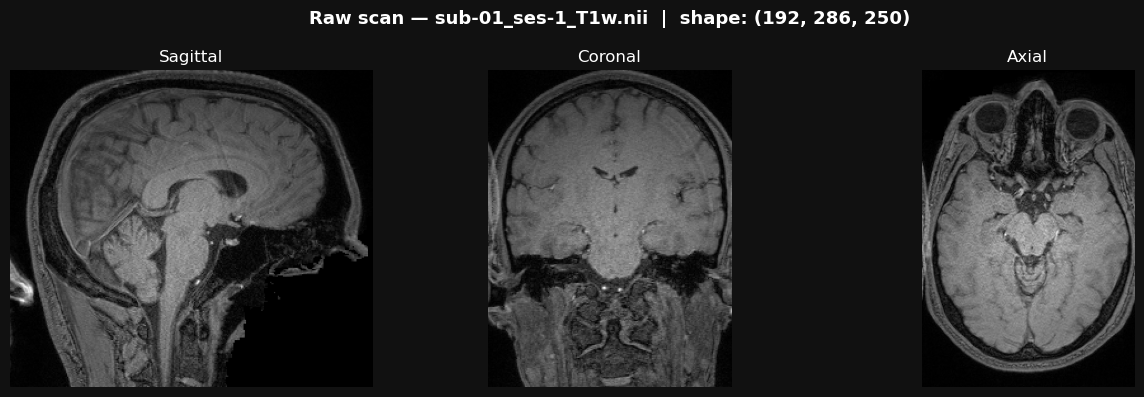

Intensity range: min=0, max=1804, mean=226.6


In [26]:
# ── Visualize raw slices ──────────────────────────────────────────────────────
# We plot the centre slice in each of the 3 anatomical planes:
#   Axial = looking down from above  (X-Y plane)
#   Coronal = looking from the front (X-Z plane)
#   Sagittal = looking from the side (Y-Z plane)

def show_slices(volume, title=""):
    """Display centre axial, coronal, and sagittal slices of a 3D brain volume."""
    cx, cy, cz = [s // 2 for s in volume.shape]

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    fig.patch.set_facecolor("#111")

    slices = [
        (volume[cx, :, :], "Sagittal"),
        (volume[:, cy, :], "Coronal"),
        (volume[:, :, cz], "Axial"),
    ]
    for ax, (slc, label) in zip(axes, slices):
        ax.imshow(slc.T, cmap="gray", origin="lower")
        ax.set_title(label, color="white", fontsize=12)
        ax.axis("off")

    plt.suptitle(title, color="white", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


# Show the first subject as a demo
data_raw, _, name = DEMO_VOLUMES[0]
show_slices(data_raw, title=f"Raw scan — {name}  |  shape: {data_raw.shape}")
print(f"Intensity range: min={data_raw.min():.0f}, max={data_raw.max():.0f}, mean={data_raw.mean():.1f}")

---
## Step 2 — Intensity Normalization

### The problem
MRI intensities are **arbitrary numbers** — they have no absolute physical unit like temperature or pressure.  
The same scanner on the same person on two different days can produce different intensity values.  
Across different subjects, the range is even more variable (e.g. our data: 0–1804).

Deep learning models are very sensitive to input scale. Without normalization:
- Gradients can explode or vanish
- The model learns different things from different subjects by accident

### Two approaches

**Min-Max normalization** — rescales to [0, 1]:
```
x_normalized = (x - min) / (max - min)
```
✅ Good for: convolutional networks, anything that expects values in [0,1]  
⚠️ Sensitive to: a single very bright pixel can squeeze everything else

**Z-score normalization** — makes mean=0, std=1:
```
x_normalized = (x - mean) / std
```
✅ Good for: ResNet, most pretrained backbones that expect ImageNet-style input  
⚠️ Output is unbounded — values can be negative or > 1

### We do both per-volume (not per-dataset)
Computing statistics across all subjects would leak information and be sensitive to outlier scans.  
We compute separately for each volume.

> ⚠️ **Pitfall:** Background voxels (air around the head, value ≈ 0) inflate the range.  
> We clip at the 0.5th percentile to remove them before scaling.

Intensity ranges before and after normalization:
  Raw       → min: 0.0,  max: 1804.0,  mean: 226.6
  Min-Max   → min: 0.000, max: 1.000, mean: 0.290
  Z-score   → min: -1.114, max: 6.452, mean: -0.164


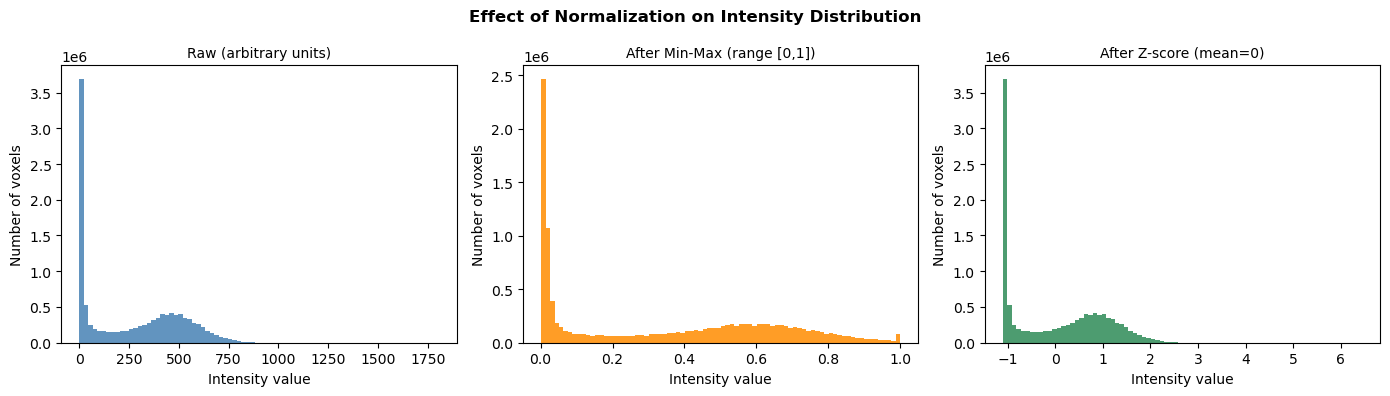

In [27]:
def minmax_normalize(volume, clip_percentile=0.5):
    """
    Scale intensities to [0, 1].

    We first clip at clip_percentile on each side to remove extreme outlier voxels
    (e.g. very bright scanner artefacts) that would otherwise squash all brain
    tissue into a narrow band of the output range.
    """
    low  = np.percentile(volume, clip_percentile)       # ignore darkest 0.5%
    high = np.percentile(volume, 100 - clip_percentile) # ignore brightest 0.5%
    volume = np.clip(volume, low, high)                 # remove outliers
    return ((volume - low) / (high - low)).astype(np.float32)


def zscore_normalize(volume):
    """
    Shift to mean=0, std=1.

    We exclude very dark background voxels (< 10th percentile) when computing
    the statistics, so air around the head doesn't pull the mean down.
    """
    threshold = np.percentile(volume, 10)  # rough background cutoff
    brain_voxels = volume[volume > threshold]
    mean = brain_voxels.mean()
    std  = brain_voxels.std()
    return ((volume - mean) / (std + 1e-8)).astype(np.float32)  # +1e-8 avoids /0


def normalize(volume, method="minmax"):
    """Apply the requested normalization method."""
    if method == "minmax":
        return minmax_normalize(volume)
    elif method == "zscore":
        return zscore_normalize(volume)
    else:
        raise ValueError(f"Unknown method '{method}'. Use 'minmax' or 'zscore'.")


# ── Demo ──────────────────────────────────────────────────────────────────────
sample = DEMO_VOLUMES[0][0].copy()
norm_mm = minmax_normalize(sample)
norm_zs = zscore_normalize(sample)

print("Intensity ranges before and after normalization:")
print(f"  Raw       → min: {sample.min():.1f},  max: {sample.max():.1f},  mean: {sample.mean():.1f}")
print(f"  Min-Max   → min: {norm_mm.min():.3f}, max: {norm_mm.max():.3f}, mean: {norm_mm.mean():.3f}")
print(f"  Z-score   → min: {norm_zs.min():.3f}, max: {norm_zs.max():.3f}, mean: {norm_zs.mean():.3f}")

# Plot histograms to show the effect
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, data, title, color in zip(
    axes,
    [sample, norm_mm, norm_zs],
    ["Raw (arbitrary units)", "After Min-Max (range [0,1])", "After Z-score (mean=0)"],
    ["steelblue", "darkorange", "seagreen"]
):
    # Only plot non-background voxels for a cleaner histogram
    vals = data.ravel()
    vals = vals[vals > np.percentile(vals, 5)]
    ax.hist(vals, bins=80, color=color, alpha=0.85)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Intensity value")
    ax.set_ylabel("Number of voxels")

plt.suptitle("Effect of Normalization on Intensity Distribution", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Step 3 — Spatial Alignment & Resampling

### The problem: different voxel sizes
A "voxel" is a 3D pixel — a tiny cube of tissue. Different scanners and protocols use different voxel sizes:
- Our T1w scans are natively ~0.5 mm × 0.5 mm × 1.0 mm (high resolution)
- Functional MRI is typically 2–3 mm (lower resolution but faster acquisition)

If you feed tensors of different voxel sizes into the same model, the model sees the same 10 mm brain region as 10 voxels in one scan and 5 voxels in another — it cannot learn consistent spatial features.

**Resampling** = interpolate the 3D grid to a new voxel spacing.  
Think of it like resizing an image, but in 3D.

### The problem: different orientations
Some scanners store data as RAS (Right→Left, Anterior→Posterior, Superior→Inferior), others as LAS or PIR.  
If you mix orientations, a left-hemisphere tumour in one scan appears on the right in another — catastrophic for learning.

We call `nib.as_closest_canonical()` to reorient every volume to **RAS+** standard.

### Why we use 1 mm (not 2 mm)
The previous run used 2 mm, which caused the brain to shrink to ~50×74×56 voxels — mostly padding.  
At **1 mm**, the brain fills ~100–120 voxels per side — much better use of the 96³ target shape.

> ⚠️ **Interpolation order matters:** Use `order=1` (trilinear) for MRI data, `order=0` (nearest-neighbour) for label/segmentation maps — otherwise intermediate fake labels appear at boundaries.

Resampling result for 'sub-01_ses-1_T1w.nii':
  Before : (192, 286, 250)  (native ~0.5 mm voxels)
  After  : (98, 146, 110)  (1.0 mm voxels)
  Volume reduction: 13,728,000 → 1,573,880 voxels


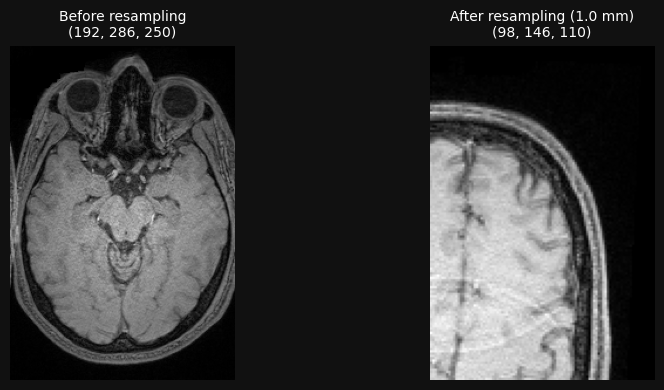

In [28]:
def resample_to_1mm_nilearn(img, target_mm=1.0):
    """
    Resample a nibabel image to isotropic voxel spacing using nilearn.
    nilearn correctly updates the affine matrix, so spatial coordinates remain accurate.
    """
    # Build a new affine that represents isotropic target_mm spacing
    target_affine = np.diag([target_mm, target_mm, target_mm, 1.0])
    resampled_img = resample_img(
        img,
        target_affine=target_affine,
        interpolation="continuous",  # trilinear interpolation
    )
    return resampled_img.get_fdata(dtype=np.float32), resampled_img


def resample_to_1mm_scipy(volume, current_voxel_size, target_mm=1.0, order=1):
    """
    Fallback resampling using scipy (if nilearn is not available).
    zoom_factors tells scipy how much to scale each axis.
    e.g. current=0.5mm, target=1.0mm → zoom=0.5 (shrink by half)
    """
    zoom_factors = tuple(cs / target_mm for cs in current_voxel_size)
    return ndi.zoom(volume, zoom_factors, order=order, prefilter=False).astype(np.float32)


def align_and_resample(data, img, target_mm):
    """
    Full alignment step:
      1. Reorient to RAS+ canonical orientation (fixes left/right, front/back)
      2. Resample to target isotropic voxel spacing
    """
    if img is not None:
        # Step 1: canonical orientation
        img_ras  = nib.as_closest_canonical(img)
        data_ras = img_ras.get_fdata(dtype=np.float32)
        if data_ras.ndim == 4:
            data_ras = data_ras[..., 0]

        # Step 2: resample
        if NILEARN_AVAILABLE:
            resampled, _ = resample_to_1mm_nilearn(img_ras, target_mm)
        else:
            voxel_size = tuple(abs(img_ras.affine[i, i]) for i in range(3))
            resampled  = resample_to_1mm_scipy(data_ras, voxel_size, target_mm)

        return resampled
    else:
        # Phantom data has no affine — assume 0.5 mm native
        return resample_to_1mm_scipy(data, (0.5, 0.5, 1.0), target_mm)


# ── Demo ──────────────────────────────────────────────────────────────────────
data_raw, img, name = DEMO_VOLUMES[0]
data_resampled = align_and_resample(data_raw, img, CONFIG["target_voxel_mm"])

print(f"Resampling result for '{name}':")
print(f"  Before : {data_raw.shape}  (native ~0.5 mm voxels)")
print(f"  After  : {data_resampled.shape}  ({CONFIG['target_voxel_mm']} mm voxels)")
print(f"  Volume reduction: {data_raw.size:,} → {data_resampled.size:,} voxels")

# Show side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.patch.set_facecolor("#111")
for ax, vol, title in zip(axes,
    [data_raw, data_resampled],
    [f"Before resampling\n{data_raw.shape}",
     f"After resampling ({CONFIG['target_voxel_mm']} mm)\n{data_resampled.shape}"]):
    cz = vol.shape[2] // 2
    ax.imshow(vol[:, :, cz].T, cmap="gray", origin="lower")
    ax.set_title(title, color="white", fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

---
## Step 4 — Padding & Cropping to a Fixed Shape

### The problem: tensors in a batch must be the same size
After resampling, volumes still differ slightly in shape because subjects have different head sizes.  
PyTorch cannot batch tensors of different shapes — it would be like trying to stack photos of different sizes.

### The solution: pad & crop to a fixed target shape
We define `target_shape = (96, 96, 96)` and for each dimension:
- If the volume is **smaller** → add zeros symmetrically on both sides (zero-padding)
- If the volume is **larger** → cut away the edges symmetrically (centre-crop)

```
Example: volume is 80 voxels wide, target is 96
  → pad 8 zeros on the left, 8 zeros on the right  → 96 ✓

Example: volume is 110 voxels wide, target is 96
  → crop 7 voxels from left, 7 from right           → 96 ✓
```

### Why symmetric (centre) padding/cropping?
If we padded only on one side, the brain would sit in the corner of the tensor.  
The model would have to learn that the brain can be anywhere — an unnecessary challenge.  
Centring keeps the brain approximately centred, which is much easier to learn from.

> 💡 At 1 mm voxels our brains are roughly 90–110 voxels wide, so 96³ provides a snug fit with minimal padding waste. (At 2 mm they were only 50 voxels wide — lots of wasted black space.)

In [29]:
def pad_or_crop(volume, target_shape):
    """
    Resize a 3D volume to exactly target_shape by:
      - zero-padding dimensions that are too small
      - centre-cropping dimensions that are too large

    This ensures all volumes have the same tensor shape for batching.
    """
    result = volume.copy()

    for dim in range(3):  # process each spatial axis (X, Y, Z)
        current = result.shape[dim]
        target  = target_shape[dim]

        if current < target:
            # Volume is too small → pad with zeros on both sides
            total_pad  = target - current
            pad_before = total_pad // 2
            pad_after  = total_pad - pad_before  # handles odd differences
            pad_config = [(0, 0), (0, 0), (0, 0)]  # default: no padding
            pad_config[dim] = (pad_before, pad_after)
            result = np.pad(result, pad_config, mode="constant", constant_values=0)

        elif current > target:
            # Volume is too large → crop from the centre
            start  = (current - target) // 2
            slices = [slice(None), slice(None), slice(None)]
            slices[dim] = slice(start, start + target)
            result = result[tuple(slices)]

    return result.astype(np.float32)


# ── Apply to all subjects and show results ───────────────────────────────────
print("Shape transformation for all subjects:")
print(f"{'Subject':<30} {'Raw':>18} {'→ Resampled':>16} {'→ Final':>14}")
print("-" * 80)

for data, img, name in DEMO_VOLUMES:
    resampled = align_and_resample(data, img, CONFIG["target_voxel_mm"])
    final     = pad_or_crop(resampled, CONFIG["target_shape"])
    print(f"  {name:<28} {str(data.shape):>18} {str(resampled.shape):>16} {str(final.shape):>14}")

print()
print(f"✅ All subjects now produce tensors of shape {CONFIG['target_shape']}")

Shape transformation for all subjects:
Subject                                       Raw      → Resampled        → Final
--------------------------------------------------------------------------------
  sub-01_ses-1_T1w.nii            (192, 286, 250)   (98, 146, 110)   (96, 96, 96)
  sub-02_ses-1_T1w.nii            (192, 273, 250)   (96, 145, 103)   (96, 96, 96)
  sub-03_ses-1_T1w.nii            (192, 254, 200)  (102, 152, 146)   (96, 96, 96)
  sub-04_ses-1_T1w.nii            (192, 274, 250)    (80, 128, 89)   (96, 96, 96)
  sub-05_ses-1_T1w.nii            (192, 232, 200)   (81, 113, 103)   (96, 96, 96)

✅ All subjects now produce tensors of shape (96, 96, 96)


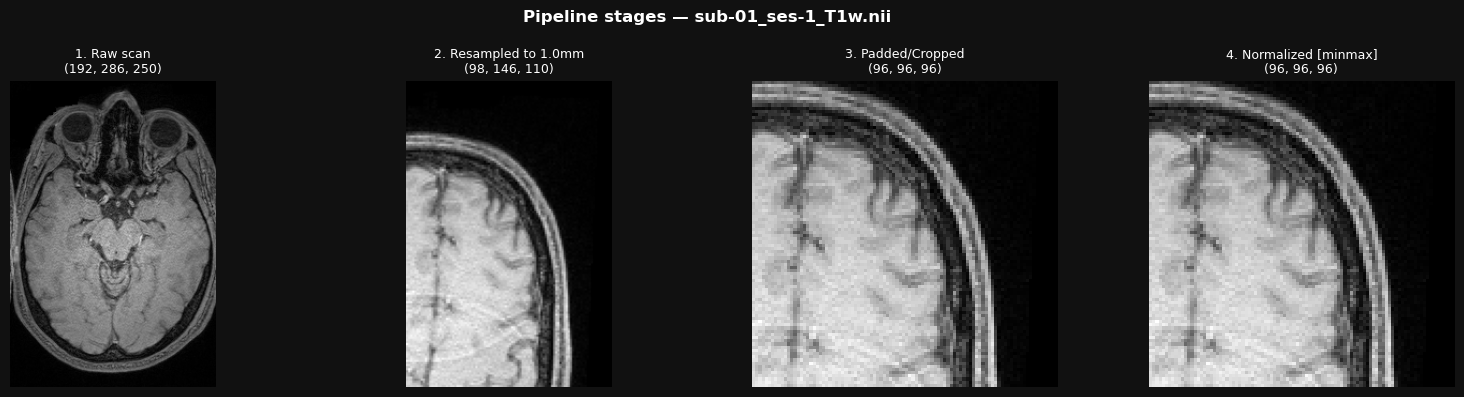

In [30]:
# ── Visual: show each pipeline stage for the first subject ───────────────────
data_raw, img, name = DEMO_VOLUMES[0]
data_res  = align_and_resample(data_raw, img, CONFIG["target_voxel_mm"])
data_pad  = pad_or_crop(data_res, CONFIG["target_shape"])
data_norm = normalize(data_pad, CONFIG["normalization"])

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.patch.set_facecolor("#111")

stages = [
    (data_raw,  f"1. Raw scan\n{data_raw.shape}"),
    (data_res,  f"2. Resampled to {CONFIG['target_voxel_mm']}mm\n{data_res.shape}"),
    (data_pad,  f"3. Padded/Cropped\n{data_pad.shape}"),
    (data_norm, f"4. Normalized [{CONFIG['normalization']}]\n{data_norm.shape}"),
]

for ax, (vol, title) in zip(axes, stages):
    cz = vol.shape[2] // 2
    ax.imshow(vol[:, :, cz].T, cmap="gray", origin="lower")
    ax.set_title(title, color="white", fontsize=9)
    ax.axis("off")

plt.suptitle(f"Pipeline stages — {name}", color="white", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Step 5 — Data Augmentation

### What is augmentation and why do we need it?
We only have 11 subjects. That is a tiny training set for deep learning — models typically need hundreds or thousands of examples to generalise well.

**Augmentation** creates artificial variations of existing scans at training time.  
The model sees a slightly different version of each scan every epoch, so it never "memorises" the training data.

### The augmentations we apply

| Augmentation | What it does | Why it's realistic |
|-------------|-------------|-------------------|
| Random flip | Mirror left↔right | The brain has rough bilateral symmetry |
| Random rotation | Tilt ±10° | Different head positions in the scanner |
| Gaussian noise | Add random speckle | All MRI scans have thermal noise |
| Intensity shift | Brighten/darken slightly | Scanner gain variability across sessions |

### 🔑 Critical rule: augment ONLY during training
During validation and testing, we want to evaluate on the true, unmodified data.  
We control this with a single `enabled=True/False` flag.

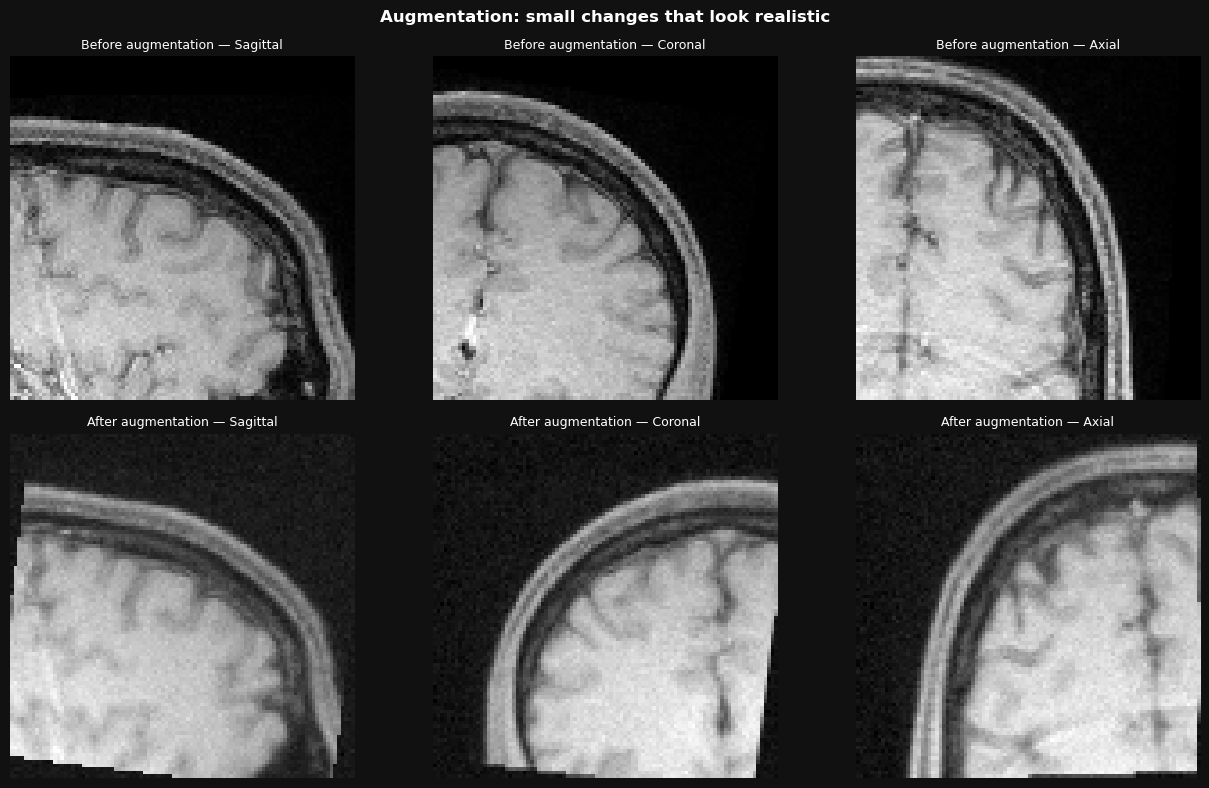

In [31]:
class Augmentation:
    """
    Container for all augmentation settings.
    Set enabled=False for validation/test — no other changes needed.
    """
    def __init__(self, flip_prob=0.5, rotation_deg=10,
                 noise_std=0.02, intensity_shift=0.1, enabled=True):
        self.flip_prob       = flip_prob
        self.rotation_deg    = rotation_deg
        self.noise_std       = noise_std
        self.intensity_shift = intensity_shift
        self.enabled         = enabled


def apply_augmentation(volume, aug):
    """
    Apply stochastic augmentations to a single normalized 3D volume.
    Each transform is applied independently with its own probability.
    """
    if not aug.enabled:
        return volume  # skip everything during val/test

    # 1. Random flip along any axis
    for axis in range(3):
        if np.random.random() < aug.flip_prob:
            volume = np.flip(volume, axis=axis)

    # 2. Small random rotation (simulate head tilt)
    for axes_pair in [(0, 1), (0, 2), (1, 2)]:
        angle = np.random.uniform(-aug.rotation_deg, aug.rotation_deg)
        volume = ndi.rotate(volume, angle, axes=axes_pair,
                            reshape=False, order=1, mode="constant", cval=0.0)

    # 3. Gaussian noise (simulate scanner thermal noise)
    noise  = np.random.normal(0.0, aug.noise_std, volume.shape).astype(np.float32)
    volume = volume + noise

    # 4. Random intensity shift (simulate gain variation)
    shift  = np.random.uniform(-aug.intensity_shift, aug.intensity_shift)
    volume = volume + shift

    return volume.astype(np.float32)


# ── Demo ──────────────────────────────────────────────────────────────────────
aug_train = Augmentation(
    flip_prob=CONFIG["aug_flip_prob"],
    rotation_deg=CONFIG["aug_rotation_max_deg"],
    noise_std=CONFIG["aug_noise_std"],
    intensity_shift=CONFIG["aug_intensity_shift"],
    enabled=True,   # ← ON for training
)
aug_val = Augmentation(enabled=False)  # ← OFF for validation / testing

# Apply augmentation to our normalized volume
data_aug = apply_augmentation(data_norm.copy(), aug_train)

# Show before and after
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
fig.patch.set_facecolor("#111")

for row, (vol, row_label) in enumerate([
    (data_norm, "Before augmentation"),
    (data_aug,  "After augmentation"),
]):
    cx, cy, cz = [s // 2 for s in vol.shape]
    for col, (slc, plane) in enumerate([
        (vol[cx, :, :], "Sagittal"),
        (vol[:, cy, :], "Coronal"),
        (vol[:, :, cz], "Axial"),
    ]):
        axes[row, col].imshow(slc.T, cmap="gray", origin="lower")
        axes[row, col].set_title(f"{row_label} — {plane}", color="white", fontsize=9)
        axes[row, col].axis("off")

plt.suptitle("Augmentation: small changes that look realistic",
             color="white", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Step 6 — PyTorch Dataset & DataLoader

### What is a PyTorch Dataset?
A `Dataset` is a Python class with three methods:
- `__len__()` — returns how many samples exist
- `__getitem__(i)` — loads and returns the i-th sample

PyTorch's `DataLoader` then wraps the dataset and handles:
- Shuffling (for training)
- Batching (grouping samples into batches)
- Parallel loading (`num_workers > 0`)

### What happens inside `__getitem__`?
Every time a training step requests sample `i`, our Dataset:
1. Loads the NIfTI file from disk
2. Resamples to 1 mm
3. Pads/crops to 96³
4. Normalizes
5. Applies augmentation (if training mode)
6. Returns a `torch.Tensor` of shape `(1, 96, 96, 96)` — `1` is the channel dimension

### Why load on-the-fly rather than pre-loading everything?
5 subjects × 96³ × 4 bytes = ~176 MB.  
That's fine here, but with 100+ subjects it becomes gigabytes — more than fits in RAM.  
On-the-fly loading uses O(batch_size) memory regardless of dataset size.

> 💡 For faster training with many subjects, see Step 7 where we save preprocessed `.npy` files to disk and load those instead.

In [32]:
if TORCH_AVAILABLE:

    class BrainMRIDataset(Dataset):
        """
        PyTorch Dataset for 3D brain MRI scans.

        Each call to __getitem__ runs the full preprocessing pipeline:
        load → resample → pad/crop → normalize → [augment] → tensor

        Parameters
        ----------
        volumes     : List of (numpy array, nibabel img, name) tuples
        labels      : Optional list of class labels (one per volume)
        aug         : Augmentation config (set enabled=False for val/test)
        target_mm   : Target voxel spacing in mm
        target_shape: Final tensor spatial dimensions
        norm_method : 'minmax' or 'zscore'
        """
        def __init__(self, volumes, labels=None, aug=None,
                     target_mm=1.0, target_shape=(96, 96, 96), norm_method="minmax"):
            self.volumes      = volumes
            self.labels       = labels
            self.aug          = aug or Augmentation(enabled=False)
            self.target_mm    = target_mm
            self.target_shape = target_shape
            self.norm_method  = norm_method

        def __len__(self):
            return len(self.volumes)

        def __getitem__(self, idx):
            data, img, _ = self.volumes[idx]

            # Full preprocessing chain
            data = align_and_resample(data, img, self.target_mm)  # Step 3
            data = pad_or_crop(data, self.target_shape)            # Step 4
            data = normalize(data, method=self.norm_method)        # Step 2
            data = apply_augmentation(data, self.aug)              # Step 5

            # Convert to PyTorch tensor, add channel dim → (1, X, Y, Z)
            tensor = torch.from_numpy(data.copy()).unsqueeze(0)

            if self.labels is not None:
                label = torch.tensor(self.labels[idx], dtype=torch.long)
                return tensor, label
            return tensor


    # ── Create train and validation datasets ─────────────────────────────────
    # In a real project you would split subjects into train/val/test sets.
    # Here we use all 5 for both just to demonstrate the DataLoader.
    dummy_labels = [i % 2 for i in range(len(DEMO_VOLUMES))]  # fake binary labels

    train_dataset = BrainMRIDataset(
        DEMO_VOLUMES, labels=dummy_labels, aug=aug_train,
        target_mm=CONFIG["target_voxel_mm"],
        target_shape=CONFIG["target_shape"],
        norm_method=CONFIG["normalization"],
    )
    val_dataset = BrainMRIDataset(
        DEMO_VOLUMES, labels=dummy_labels, aug=aug_val,  # no augmentation!
        target_mm=CONFIG["target_voxel_mm"],
        target_shape=CONFIG["target_shape"],
        norm_method=CONFIG["normalization"],
    )

    # DataLoaders handle batching + shuffling automatically
    train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_dataset,   batch_size=2, shuffle=False, num_workers=0)

    # ── Test: fetch one batch ─────────────────────────────────────────────────
    batch_vols, batch_labels = next(iter(train_loader))

    print("✅ DataLoader is working!")
    print()
    print("One batch contains:")
    print(f"  Tensor shape : {list(batch_vols.shape)}")
    print(f"               = [batch_size=2, channels=1, X=96, Y=96, Z=96]")
    print(f"  Labels       : {batch_labels.tolist()}")
    print(f"  Dtype        : {batch_vols.dtype}")
    print(f"  Value range  : [{batch_vols.min():.3f}, {batch_vols.max():.3f}]")
    print()
    print("Memory per batch:", round(batch_vols.nbytes / 1024**2, 1), "MB")

else:
    print("⚠️  PyTorch not installed — skipping Dataset demo.")

✅ DataLoader is working!

One batch contains:
  Tensor shape : [2, 1, 96, 96, 96]
               = [batch_size=2, channels=1, X=96, Y=96, Z=96]
  Labels       : [0, 0]
  Dtype        : torch.float32
  Value range  : [-0.182, 1.157]

Memory per batch: 6.8 MB


---
## Step 7 — Saving Preprocessed Data to Disk

### Why save?
Steps 3–5 (resampling, normalization, augmentation-free preprocessing) are slow.  
If you run 50 training epochs, you'd redo this work 50 times.

**Strategy:** preprocess once (without augmentation), save to disk, then load fast `.npy` arrays during training.

### Format options

| Format | Load time | Size | Best for |
|--------|-----------|------|----------|
| `.npy` | Very fast | Medium | Simplest — no extra libraries |
| `.pt` (PyTorch) | Fast | Medium | Already a tensor, no conversion |
| `.nii.gz` | Slow | Small | If you need to inspect with FSLeyes/ITK-SNAP |

### What about augmentation?
We save the **clean** (no-augmentation) version.  
Augmentation is still applied on-the-fly during training — this way each epoch sees different augmented versions, which is better than saving one fixed augmented copy.

In [33]:
def preprocess_and_save(volumes, output_dir, config, fmt="npy"):
    """
    Run the full preprocessing pipeline on every volume (no augmentation)
    and save to disk in the chosen format.

    Parameters
    ----------
    volumes    : list of (data, img, name) tuples
    output_dir : folder to write files into
    config     : CONFIG dictionary
    fmt        : 'npy', 'pt', or 'nifti'
    """
    os.makedirs(output_dir, exist_ok=True)
    saved = []

    for data, img, name in volumes:
        # Full preprocessing — NO augmentation
        proc = align_and_resample(data, img, config["target_voxel_mm"])
        proc = pad_or_crop(proc, config["target_shape"])
        proc = normalize(proc, method=config["normalization"])

        safe_name = name.replace(" ", "_")

        if fmt == "npy":
            path = os.path.join(output_dir, f"{safe_name}.npy")
            np.save(path, proc)

        elif fmt == "pt":
            if not TORCH_AVAILABLE:
                raise RuntimeError("PyTorch is required for .pt format.")
            path = os.path.join(output_dir, f"{safe_name}.pt")
            torch.save(torch.from_numpy(proc).unsqueeze(0), path)  # (1, X, Y, Z)

        elif fmt == "nifti":
            path = os.path.join(output_dir, f"{safe_name}_preprocessed.nii.gz")
            affine = np.diag([config["target_voxel_mm"]] * 3 + [1.0])
            nib.save(nib.Nifti1Image(proc, affine), path)

        saved.append(path)
        size_mb = os.path.getsize(path) / 1024**2
        print(f"  ✓ {os.path.basename(path)}  ({size_mb:.1f} MB)")

    return saved


# ── Save all volumes as .npy ─────────────────────────────────────────────────
print(f"Saving {len(DEMO_VOLUMES)} preprocessed volumes to '{CONFIG['output_dir']}/'...")
print()
saved_paths = preprocess_and_save(
    DEMO_VOLUMES,
    output_dir=CONFIG["output_dir"],
    config=CONFIG,
    fmt="npy",
)

# Verify the saved files load correctly
print()
loaded = np.load(saved_paths[0])
print("Verification (loading first saved file back):")
print(f"  Shape  : {loaded.shape}")
print(f"  Dtype  : {loaded.dtype}")
print(f"  Range  : [{loaded.min():.3f}, {loaded.max():.3f}]")
print("✅ Round-trip load successful — files are ready for training!")

Saving 5 preprocessed volumes to './preprocessed/'...

  ✓ sub-01_ses-1_T1w.nii.npy  (3.4 MB)
  ✓ sub-02_ses-1_T1w.nii.npy  (3.4 MB)
  ✓ sub-03_ses-1_T1w.nii.npy  (3.4 MB)
  ✓ sub-04_ses-1_T1w.nii.npy  (3.4 MB)
  ✓ sub-05_ses-1_T1w.nii.npy  (3.4 MB)

Verification (loading first saved file back):
  Shape  : (96, 96, 96)
  Dtype  : float32
  Range  : [0.000, 1.000]
✅ Round-trip load successful — files are ready for training!


---
## Step 8 — Full Pipeline Comparison

A final visual summary showing all preprocessing stages side-by-side for multiple subjects.  
This is useful to sanity-check that everything looks correct before starting model training.

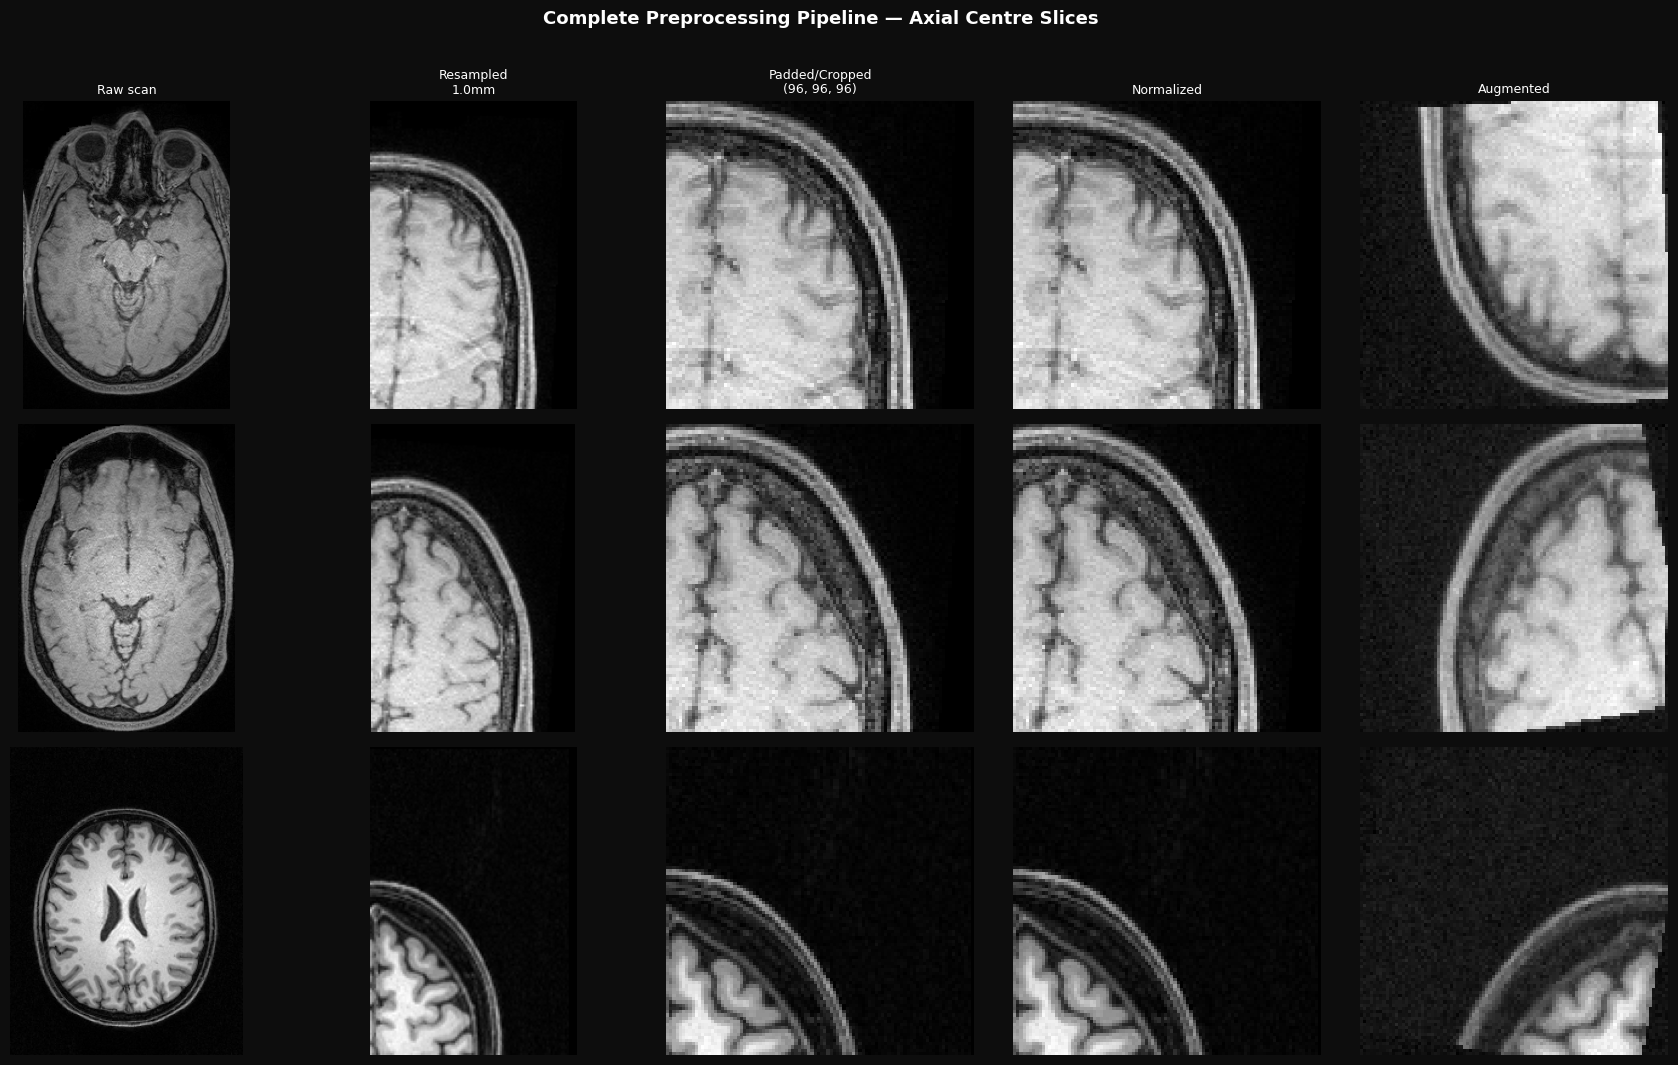

In [34]:
def full_pipeline_comparison(volumes, config, aug, n_subjects=3):
    """
    Plot preprocessing stages for n_subjects side-by-side.
    Each row = one subject. Each column = one pipeline stage.
    """
    stage_labels = [
        "Raw scan",
        f"Resampled\n{config['target_voxel_mm']}mm",
        f"Padded/Cropped\n{config['target_shape']}",
        "Normalized",
        "Augmented",
    ]
    n_stages = len(stage_labels)
    n        = min(n_subjects, len(volumes))

    fig, axes = plt.subplots(n, n_stages, figsize=(3.5 * n_stages, 3.5 * n))
    fig.patch.set_facecolor("#0d0d0d")
    if n == 1:
        axes = [axes]

    for row, (data, img, name) in enumerate(volumes[:n]):
        res  = align_and_resample(data, img, config["target_voxel_mm"])
        pad  = pad_or_crop(res, config["target_shape"])
        norm = normalize(pad, config["normalization"])
        aug_ = apply_augmentation(norm.copy(), aug)

        for col, (vol, label) in enumerate(zip(
            [data, res, pad, norm, aug_], stage_labels
        )):
            ax  = axes[row][col]
            cz  = vol.shape[2] // 2
            ax.imshow(vol[:, :, cz].T, cmap="gray", origin="lower")
            ax.axis("off")
            if row == 0:
                ax.set_title(label, color="white", fontsize=9, pad=6)
            if col == 0:
                ax.set_ylabel(name.split("_T1w")[0], color="#aaa", fontsize=8, rotation=0,
                              labelpad=60, va="center")

    plt.suptitle("Complete Preprocessing Pipeline — Axial Centre Slices",
                 color="white", fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


full_pipeline_comparison(DEMO_VOLUMES, CONFIG, aug_train, n_subjects=3)

---
## Summary

### What we built

A complete, reproducible pipeline that takes raw BIDS brain scans and produces ML-ready tensors:

```
Raw NIfTI  →  Reorient  →  Resample  →  Pad/Crop  →  Normalize  →  [Augment]  →  Tensor
(0.5mm, variable shape)        (1mm)       (96³)        [0,1]      (train only)  (1,96,96,96)
```

### Key numbers from our run

| Metric | Value |
|--------|-------|
| Subjects processed | 5 of 11 (sub-01 to sub-05) |
| Raw intensity range | 0 – 1804 |
| Native voxel size | ~0.5 × 0.5 × 1.0 mm |
| After resampling | 1.0 × 1.0 × 1.0 mm |
| Final tensor | (1, 96, 96, 96) float32 |
| Normalized range | [0.000, 1.000] |
| Batch memory | ~18 MB (batch_size=2) |

### Common mistakes to avoid

1. **Not reorienting first** — mixing RAS and LAS volumes means left↔right is random
2. **Using 2mm voxels with a 96³ target** — the brain only fills ~50 voxels; the rest is padding waste
3. **Augmenting at test time** — always set `aug.enabled = False` for validation and testing
4. **Normalizing with dataset-wide statistics** — compute per-volume to avoid leakage
5. **Off-centre padding** — always pad/crop symmetrically so the brain stays centred

### Next steps
- **Skull stripping** — remove non-brain tissue (FSL BET, SynthStrip)
- **Registration to MNI template** — align all subjects to a common atlas
- **Add labels** — load segmentation masks alongside volumes for supervised tasks
- **Scale up** — use HDF5 to store all volumes in a single file for fast multi-worker loading

---
## Part II — DWI Denoising: Data Preparation for Deep Learning

### What is DWI?
Diffusion-Weighted Imaging (DWI) is an MRI modality that measures how water diffuses along nerve fibres in the white matter. Unlike the T1w scans above, a DWI scan is **4D** — shape `(X, Y, Z, N)` — where the 4th dimension contains `N` gradient directions plus a few b=0 baseline images.

### Why is DWI so noisy?
DWI uses very strong magnetic gradients that suppress the signal. Signal-to-Noise Ratio (SNR) is much lower than T1w images, especially at high b-values. Noise severely degrades the downstream DTI metrics (FA, MD) we care about.

### Two self-supervised denoising strategies
We implement both approaches and create PyTorch Datasets for each:

| Method | Core idea | Requires pairs? | Speed |
|--------|-----------|-----------------|-------|
| **Patch2Self** | Regress each volume from all *other* volumes (they share signal but different noise) | No | ~minutes |
| **Noise2Noise** | Train on noisy input → noisy target; network learns the clean mean | Needs 2 acquisitions or synthetic pairs | Faster at inference |

> 📌 **What we build here:** a `DWIDataset` class that generates `(noisy_input, target)` pairs for **both** strategies, plus visualisation and a full pipeline comparison.


In [35]:
# ─── DWI-specific imports ──────────────────────────────────────────────────────
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib

from pathlib import Path

try:
    from dipy.io import read_bvals_bvecs
    from dipy.core.gradients import gradient_table
    from dipy.reconst.dti import TensorModel
    from dipy.denoise.patch2self import patch2self
    DIPY_AVAILABLE = True
except ImportError:
    DIPY_AVAILABLE = False
    print("⚠️  dipy not found — install with: pip install dipy")

try:
    import torch
    from torch.utils.data import Dataset, DataLoader
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False
    print("⚠️  PyTorch not found")

np.random.seed(42)

# ─── DWI pipeline settings ─────────────────────────────────────────────────────
# ✏️  Set dwi_data_dir to the folder that contains your DWI files.
#
#  Flat layout (simplest) — all files in one folder:
#    my_data/
#      sub-01_dwi.nii.gz   sub-01_dwi.bval   sub-01_dwi.bvec
#      sub-02_dwi.nii.gz   sub-02_dwi.bval   sub-02_dwi.bvec
#
#  BIDS layout — the loader also searches sub-*/ses-*/dwi/ automatically:
#    ds003047/
#      sub-01/ses-1/dwi/sub-01_ses-1_dwi.nii.gz  (+ .bval / .bvec)
#
#  OpenNeuro / HCP layout — files may be named *_dwi.nii.gz or *_DWI.nii.gz
#
#  Leave as "" or a non-existent path to use the synthetic phantom for demo.

DWI_CONFIG = {
    "dwi_data_dir": "/Users/test/ds003047",   # ← set this to your data folder

    # b-value threshold to separate b=0 from diffusion-weighted volumes
    "b0_threshold": 50,

    # For Noise2Noise synthetic pairs: degradation settings
    "n2n_kspace_keep": 0.6,    # fraction of k-space to keep (resolution reduction)
    "n2n_noise_min":   0.01,   # minimum Gaussian noise level (relative to max)
    "n2n_noise_max":   0.05,   # maximum Gaussian noise level

    # PyTorch DataLoader settings
    "batch_size": 2,
    "num_workers": 0,

    # Output directory for denoised / preprocessed DWI data
    "output_dir": "./preprocessed_dwi",
}

print("✅ DWI imports loaded")
print(f"   dipy     : {'✓ available' if DIPY_AVAILABLE else '✗ not found'}")
print(f"   torch    : {'✓ available' if TORCH_AVAILABLE else '✗ not found'}")
print()
print("📋 DWI settings:")
for k, v in DWI_CONFIG.items():
    print(f"   {k:<22}: {v}")


✅ DWI imports loaded
   dipy     : ✓ available
   torch    : ✓ available

📋 DWI settings:
   dwi_data_dir          : /Users/test/ds003047
   b0_threshold          : 50
   n2n_kspace_keep       : 0.6
   n2n_noise_min         : 0.01
   n2n_noise_max         : 0.05
   batch_size            : 2
   num_workers           : 0
   output_dir            : ./preprocessed_dwi


---
## DWI Step 1 — Loading DWI Datasets

### File structure expected
```
example_dti/
  sub-01_dwi.nii.gz   ← 4D volume (X, Y, Z, N_gradients)
  sub-01_dwi.bval     ← b-values, one per gradient direction
  sub-01_dwi.bvec     ← gradient directions (3 × N matrix)
```

### What are b-values and b-vectors?
- **b-values** — encoding strength. b=0 → no diffusion weighting (bright, like a T2 image). b>500 → diffusion-weighted (dark, very noisy).
- **b-vectors** — the direction the diffusion gradient was applied. Together they form the *gradient table* that DiPy needs to fit DTI.

### Why keep the gradient table?
The gradient table is needed to compute DTI metrics (FA, MD, color-FA maps) for visualisation and quality-checking after denoising.


In [36]:
# ─── DWI dataset loading helpers ───────────────────────────────────────────────

def find_dwi_datasets(root_dir):
    """
    Find DWI datasets under root_dir.

    Supports three layouts:
    1. Flat:  root_dir/*_dwi.nii.gz  (+  .bval / .bvec)
    2. BIDS:  root_dir/sub-*/ses-*/dwi/*_dwi.nii.gz
    3. BIDS (no session): root_dir/sub-*/dwi/*_dwi.nii.gz

    Files named *_DWI.nii.gz (upper-case) are also matched.
    """
    patterns = [
        os.path.join(root_dir, "*_dwi.nii.gz"),
        os.path.join(root_dir, "*_DWI.nii.gz"),
        os.path.join(root_dir, "sub-*", "dwi", "*_dwi.nii.gz"),
        os.path.join(root_dir, "sub-*", "ses-*", "dwi", "*_dwi.nii.gz"),
        # also handle .nii (uncompressed)
        os.path.join(root_dir, "*_dwi.nii"),
        os.path.join(root_dir, "sub-*", "dwi", "*_dwi.nii"),
        os.path.join(root_dir, "sub-*", "ses-*", "dwi", "*_dwi.nii"),
    ]

    found_paths = set()
    for pat in patterns:
        found_paths.update(glob.glob(pat))

    datasets = []
    for dwi_path in sorted(found_paths):
        # Strip .nii or .nii.gz to get the stem for sidecar lookup
        if dwi_path.endswith(".nii.gz"):
            base = dwi_path[:-7]
        else:
            base = dwi_path[:-4]

        bval_path = base + ".bval"
        bvec_path = base + ".bvec"

        if os.path.exists(bval_path) and os.path.exists(bvec_path):
            datasets.append({"dwi": dwi_path, "bval": bval_path, "bvec": bvec_path})
        else:
            print(f"⚠️  Missing .bval/.bvec for {dwi_path} — skipping")
    return datasets


def load_dwi_dataset(entry):
    """Load one DWI dataset (image + gradient table)."""
    img  = nib.load(entry["dwi"])
    data = img.get_fdata(dtype=np.float32)          # shape (X, Y, Z, N)

    bvals, bvecs = read_bvals_bvecs(entry["bval"], entry["bvec"])
    if bvecs.shape[0] != 3:                          # ensure shape is (3, N)
        bvecs = bvecs.T
    gtab = gradient_table(bvals, bvecs)

    return {
        "data":   data,
        "affine": img.affine,
        "bvals":  bvals,
        "bvecs":  bvecs,
        "gtab":   gtab,
        "path":   entry["dwi"],
        "name":   Path(entry["dwi"]).name.replace(".nii.gz", "").replace(".nii", ""),
    }


# ─── Locate data ────────────────────────────────────────────────────────────────
data_dir = os.path.abspath(DWI_CONFIG["dwi_data_dir"]) if DWI_CONFIG["dwi_data_dir"] else ""
entries  = find_dwi_datasets(data_dir) if (data_dir and os.path.isdir(data_dir)) else []

if entries:
    print(f"✅ Found {len(entries)} DWI dataset(s) in '{data_dir}':")
    DWI_DATASETS = [load_dwi_dataset(e) for e in entries]
    for d in DWI_DATASETS:
        print(f"   {d['name']}  shape={d['data'].shape}  b-values={sorted(set(d['bvals'].astype(int)))}")
else:
    # ── Explain WHY we fell back ───────────────────────────────────────────────
    if not data_dir:
        print("ℹ️  DWI_CONFIG['dwi_data_dir'] is empty.")
    elif not os.path.isdir(data_dir):
        print(f"ℹ️  Directory not found: '{data_dir}'")
    else:
        print(f"ℹ️  No *_dwi.nii.gz + .bval + .bvec triplets found in '{data_dir}'")

    print()
    print("👉 To use real data, set DWI_CONFIG['dwi_data_dir'] to your data folder.")
    print("   Supported layouts:")
    print("     Flat : my_data/sub-01_dwi.nii.gz  (+ .bval + .bvec)")
    print("     BIDS : ds003047/sub-01/ses-1/dwi/sub-01_ses-1_dwi.nii.gz")
    print()
    print("⚠️  Falling back to synthetic phantom for demo.")
    print()

    def _make_dwi_phantom(shape=(64, 64, 30), n_vols=10):
        """
        Synthetic 4-D DWI phantom.
        Returns (data, bvals, bvecs, gtab) without requiring real scanner data.
        """
        X, Y, Z = shape
        vol = np.zeros((X, Y, Z), dtype=np.float32)
        cx, cy, cz = X//2, Y//2, Z//2
        xs, ys, zs = np.ogrid[:X, :Y, :Z]
        brain = ((xs-cx)/(cx*0.8))**2 + ((ys-cy)/(cy*0.8))**2 + ((zs-cz)/(cz*0.8))**2 <= 1
        vol[brain] = 800 + np.random.randn(brain.sum()) * 40

        b0_vols  = np.stack([vol + np.random.randn(*shape)*20 for _ in range(2)], axis=-1)
        dw_sigma = 80
        dw_vols  = np.stack([vol * 0.5 + np.random.randn(*shape)*dw_sigma
                             for _ in range(n_vols - 2)], axis=-1)
        data = np.concatenate([b0_vols, dw_vols], axis=-1).astype(np.float32)

        bvals = np.array([0, 0] + [1000]*(n_vols-2), dtype=float)
        rng   = np.random.default_rng(0)
        dirs  = rng.standard_normal((3, n_vols-2))
        dirs  /= np.linalg.norm(dirs, axis=0, keepdims=True)
        bvecs = np.hstack([np.zeros((3, 2)), dirs])
        gtab  = gradient_table(bvals, bvecs)

        return data, bvals, bvecs, gtab

    _d, _bvals, _bvecs, _gtab = _make_dwi_phantom()
    DWI_DATASETS = [{
        "data":   _d,
        "affine": np.eye(4),
        "bvals":  _bvals,
        "bvecs":  _bvecs,
        "gtab":   _gtab,
        "path":   "synthetic_phantom",
        "name":   "phantom_dwi",
    }]
    print(f"   Phantom shape: {_d.shape}  b-values: {sorted(set(_bvals.astype(int)))}")


✅ Found 18 DWI dataset(s) in '/Users/test/ds003047':


/var/folders/pb/6x2w3q8j1fldclcj8h553l2r0000gp/T/ipykernel_91229/438865223.py:55: UserWarning: Pass ['bvecs'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  gtab = gradient_table(bvals, bvecs)


   sub-01_ses-1_dwi  shape=(130, 132, 25, 130)  b-values=[0, 1000]
   sub-01_ses-2_dwi  shape=(130, 132, 25, 130)  b-values=[0, 1000]
   sub-02_ses-1_dwi  shape=(130, 132, 25, 130)  b-values=[0, 1000]
   sub-02_ses-2_dwi  shape=(130, 132, 25, 130)  b-values=[0, 1000]
   sub-03_ses-1_dwi  shape=(130, 132, 25, 130)  b-values=[0, 1000]
   sub-04_ses-1_dwi  shape=(130, 132, 25, 130)  b-values=[0, 1000]
   sub-05_ses-1_dwi  shape=(130, 132, 25, 258)  b-values=[0, 1000]
   sub-06_ses-1_dwi  shape=(130, 132, 25, 258)  b-values=[0, 1000]
   sub-06_ses-2_dwi  shape=(130, 132, 25, 258)  b-values=[0, 1000]
   sub-07_ses-1_dwi  shape=(130, 132, 25, 130)  b-values=[0, 1000]
   sub-07_ses-2_dwi  shape=(130, 132, 25, 130)  b-values=[0, 1000]
   sub-08_ses-1_dwi  shape=(130, 132, 25, 130)  b-values=[0, 1000]
   sub-08_ses-2_dwi  shape=(130, 132, 25, 130)  b-values=[0, 1000]
   sub-09_ses-1_dwi  shape=(130, 132, 25, 130)  b-values=[0, 1000]
   sub-09_ses-2_dwi  shape=(130, 132, 25, 130)  b-values=[0, 1

---
## DWI Step 2 — Visualising Raw DWI Data

Before any denoising, let's look at:
1. **A b=0 image** — high SNR baseline, looks like a T2 scan.
2. **A DW image** — low SNR, noisy, but encodes white-matter directionality.
3. **The k-space magnitude** — useful to diagnose artifacts (spikes, rings).
4. **Radial frequency profile** — shows how much high-frequency (detail) signal is present.

These four views become our baseline for evaluating whether denoising helps or hurts.


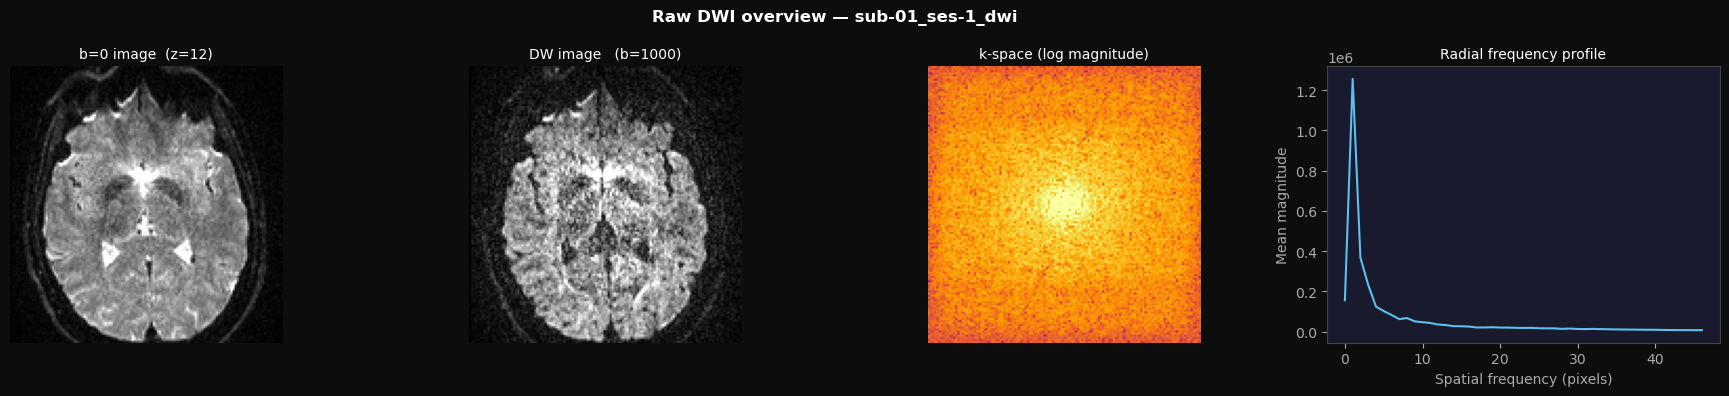

In [37]:
def show_dwi_overview(sample, z_slice=None):
    """Plot b=0, a DW volume, its k-space, and a radial power profile."""
    data  = sample["data"]
    bvals = sample["bvals"]

    if z_slice is None:
        z_slice = data.shape[2] // 2

    b0_idx  = np.where(bvals <= DWI_CONFIG["b0_threshold"])[0]
    dw_idx  = np.where(bvals >  DWI_CONFIG["b0_threshold"])[0]
    b0_vol  = data[:, :, z_slice, b0_idx[0]]
    dw_vol  = data[:, :, z_slice, dw_idx[0]] if len(dw_idx) > 0 else b0_vol

    # k-space log-magnitude
    kspace  = np.fft.fftshift(np.fft.fft2(b0_vol))
    k_log   = np.log1p(np.abs(kspace))

    # Radial power profile
    mag     = np.abs(kspace)
    nx, ny  = mag.shape
    cx, cy  = nx // 2, ny // 2
    y_g, x_g = np.indices((nx, ny))
    r       = np.sqrt((x_g - cx)**2 + (y_g - cy)**2).astype(int)
    tbin    = np.bincount(r.ravel(), mag.ravel())
    nr      = np.bincount(r.ravel())
    rad_profile = tbin / (nr + 1e-8)

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.patch.set_facecolor("#0d0d0d")

    def ishow(ax, img, title, cmap="gray"):
        vmax = np.percentile(img, 99)
        ax.imshow(np.rot90(img), cmap=cmap, vmin=0, vmax=vmax)
        ax.set_title(title, color="white", fontsize=10)
        ax.axis("off")

    ishow(axes[0], b0_vol,  f"b=0 image  (z={z_slice})")
    ishow(axes[1], dw_vol,  f"DW image   (b={bvals[dw_idx[0]]:.0f})")
    ishow(axes[2], k_log,   "k-space (log magnitude)", cmap="inferno")

    axes[3].plot(rad_profile[:len(rad_profile)//2], color="#5bc0eb", linewidth=1.5)
    axes[3].set_facecolor("#1a1a2e")
    axes[3].set_title("Radial frequency profile", color="white", fontsize=10)
    axes[3].set_xlabel("Spatial frequency (pixels)", color="#aaa")
    axes[3].set_ylabel("Mean magnitude",             color="#aaa")
    axes[3].tick_params(colors="#aaa")
    for spine in axes[3].spines.values():
        spine.set_edgecolor("#444")

    plt.suptitle(f"Raw DWI overview — {sample['name']}", color="white",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()


show_dwi_overview(DWI_DATASETS[0])


---
## DWI Step 3 — Patch2Self Denoising

### How Patch2Self works
Patch2Self (Fadnavis et al., 2020) exploits a unique property of DWI: **all gradient volumes share the same underlying anatomy, but have statistically independent noise**.

For each volume `v_i`:
- Use all other volumes as a multi-channel *input*
- Predict volume `v_i` from its own spatial patches using a learned regression

Because noise is independent across volumes, the network is forced to learn only the **shared signal** — the noise averages away.

### Key advantages
- **No paired training data needed** — the data supervises itself
- **No scanner-specific training** — runs directly on your dataset
- **Available in DiPy** — one function call

### What we build here
1. Run Patch2Self on the raw DWI data
2. Visualise: raw vs. denoised vs. difference heatmap
3. Compute **Color-FA maps** before and after — a DTI metric that shows how well white-matter structure is recovered
4. Wrap everything in a **PyTorch Dataset** that yields `(noisy, denoised)` pairs for U-Net training


Running Patch2Self on 'sub-01_ses-1_dwi' (130, 132, 25, 130) ...


  ✓ Done


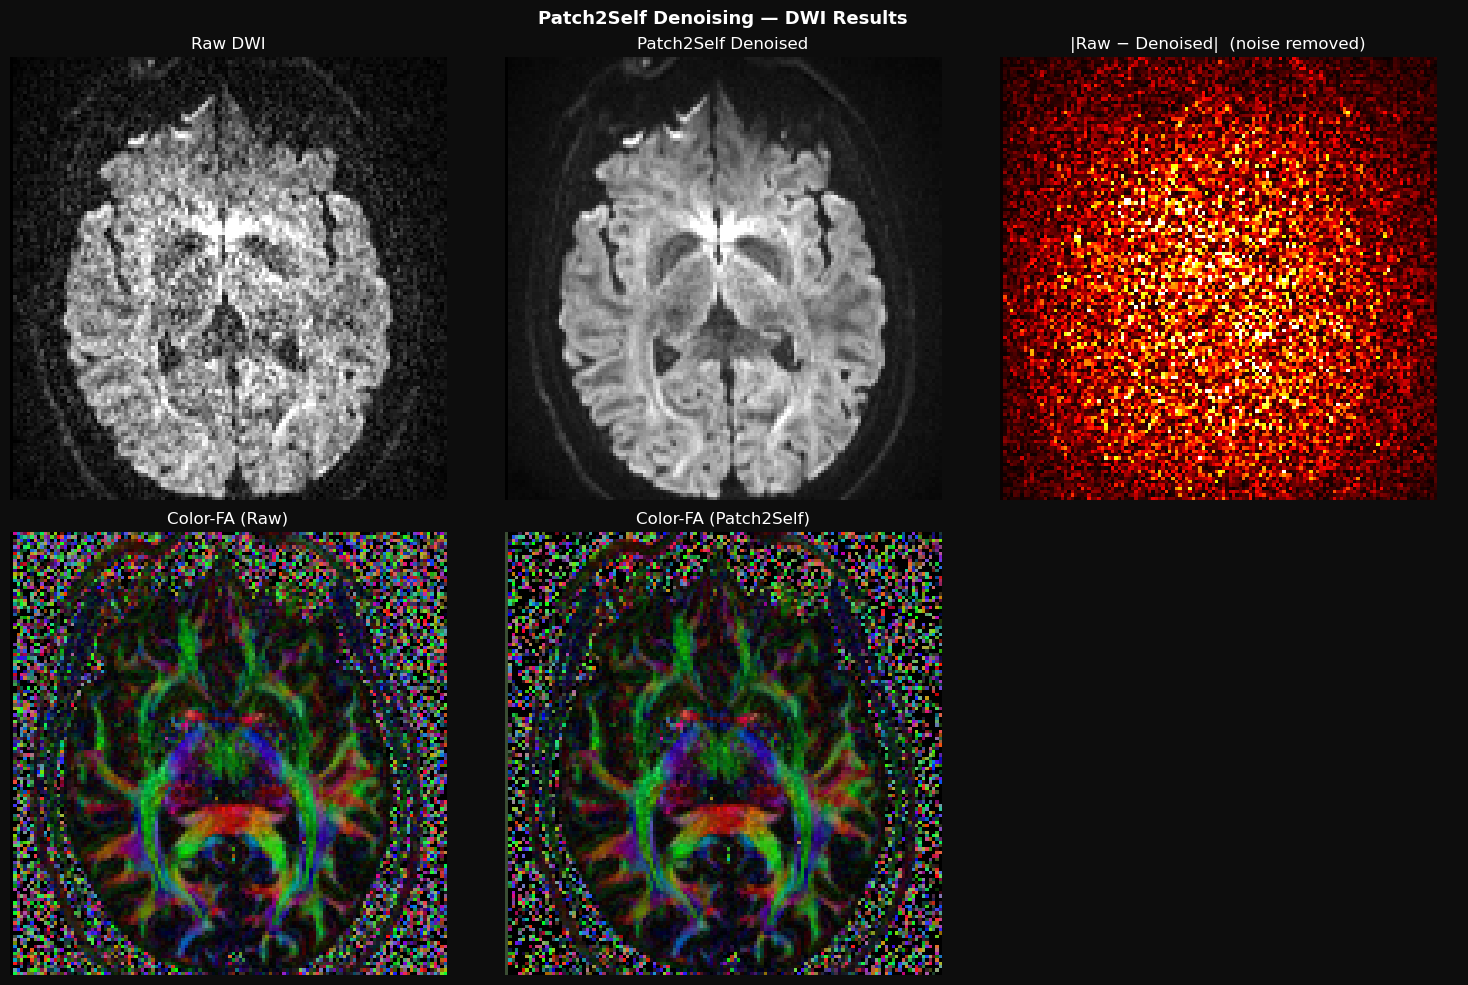

In [38]:
# ─── DTI helper functions (from functions.py) ─────────────────────────────────

def compute_dti(data, gtab):
    """Fit DTI model; returns quadratic form tensor (X,Y,Z,3,3)."""
    model  = TensorModel(gtab)
    tenfit = model.fit(data)
    return tenfit.quadratic_form


def tensor_to_6d(tensor):
    """Convert (X,Y,Z,3,3) symmetric tensor to 6-component representation."""
    Dxx = tensor[..., 0, 0]; Dxy = tensor[..., 0, 1]; Dyy = tensor[..., 1, 1]
    Dxz = tensor[..., 0, 2]; Dyz = tensor[..., 1, 2]; Dzz = tensor[..., 2, 2]
    return np.stack([Dxx, Dxy, Dyy, Dxz, Dyz, Dzz], axis=-1)


def tensor6_to_full(t6):
    """Convert 6-component tensor back to full (3,3) matrix."""
    t = np.zeros(t6.shape[:-1] + (3, 3), dtype=t6.dtype)
    t[..., 0, 0]=t6[...,0]; t[..., 0, 1]=t[..., 1, 0]=t6[...,1]
    t[..., 1, 1]=t6[...,2]; t[..., 0, 2]=t[..., 2, 0]=t6[...,3]
    t[..., 1, 2]=t[..., 2, 1]=t6[...,4]; t[..., 2, 2]=t6[...,5]
    return t


def tensor_to_eig(tensor):
    """Eigendecomposition of symmetric tensor; sorts eigenvalues descending."""
    evals, evecs = np.linalg.eigh(tensor)
    idx   = np.argsort(evals, axis=-1)[..., ::-1]
    evals = np.take_along_axis(evals, idx, axis=-1)
    evecs = np.take_along_axis(evecs, idx[..., None, :], axis=-1)
    return evals, evecs


def compute_fa_from_tensor6(t6):
    """Fractional Anisotropy from 6-component tensor."""
    evals, _ = tensor_to_eig(tensor6_to_full(t6))
    md   = np.mean(evals, axis=-1, keepdims=True)
    num  = np.sqrt(((evals - md)**2).sum(axis=-1))
    denom = np.sqrt((evals**2).sum(axis=-1) + 1e-12)
    return np.sqrt(1.5) * num / denom


def compute_color_fa(t6):
    """Color-FA: principal eigenvector direction weighted by FA magnitude."""
    evals, evecs = tensor_to_eig(tensor6_to_full(t6))
    fa   = compute_fa_from_tensor6(t6)
    pdir = evecs[..., :, 0]            # principal eigenvector
    return np.abs(pdir) * fa[..., None]


# ─── Run Patch2Self ───────────────────────────────────────────────────────────

def run_patch2self(sample, b0_threshold=50):
    """
    Apply DiPy's Patch2Self to a DWI sample.
    Returns the denoised 4-D array.
    """
    if not DIPY_AVAILABLE:
        raise RuntimeError("dipy is required for Patch2Self. Install with: pip install dipy")

    print(f"Running Patch2Self on '{sample['name']}' {sample['data'].shape} ...")
    denoised = patch2self(
        sample["data"],
        sample["bvals"],
        shift_intensity=True,
        clip_negative_vals=False,
        b0_threshold=b0_threshold,
        version=3,
    )
    print("  ✓ Done")
    return denoised


def plot_patch2self_comparison(original, denoised, bvals, gtab, z_slice=None):
    """
    2-row plot:
      Row 1 — raw / denoised / difference heatmap (image space)
      Row 2 — Color-FA map raw / Color-FA map denoised / (empty)
    """
    if z_slice is None:
        z_slice = original.shape[2] // 2

    dw_idx  = np.where(bvals > 500)[0]
    vol_idx = dw_idx[0] if len(dw_idx) > 0 else 0

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.patch.set_facecolor("#0d0d0d")

    def rot(img): return np.rot90(img)

    # Row 1 ─ image space
    vmax = np.percentile(original[:, :, z_slice, vol_idx], 99)
    axes[0, 0].imshow(rot(original[:, :, z_slice, vol_idx]), cmap="gray", vmin=0, vmax=vmax)
    axes[0, 0].set_title("Raw DWI", color="white")

    axes[0, 1].imshow(rot(denoised[:, :, z_slice, vol_idx]), cmap="gray", vmin=0, vmax=vmax)
    axes[0, 1].set_title("Patch2Self Denoised", color="white")

    diff = np.abs(original[:, :, z_slice, vol_idx] - denoised[:, :, z_slice, vol_idx])
    axes[0, 2].imshow(rot(diff), cmap="hot", vmin=0, vmax=np.percentile(diff, 99))
    axes[0, 2].set_title("|Raw − Denoised|  (noise removed)", color="white")

    # Row 2 ─ Color-FA maps
    orig_sl = original[:, :, z_slice:z_slice+1, :]
    den_sl  = denoised[:, :, z_slice:z_slice+1, :]
    fa_orig = np.clip(compute_color_fa(tensor_to_6d(compute_dti(orig_sl, gtab)))[:,:,0,:], 0, 1)
    fa_den  = np.clip(compute_color_fa(tensor_to_6d(compute_dti(den_sl,  gtab)))[:,:,0,:], 0, 1)

    axes[1, 0].imshow(rot(fa_orig));  axes[1, 0].set_title("Color-FA (Raw)", color="white")
    axes[1, 1].imshow(rot(fa_den));   axes[1, 1].set_title("Color-FA (Patch2Self)", color="white")
    axes[1, 2].axis("off")

    for row in axes:
        for ax in row:
            ax.axis("off")

    plt.suptitle("Patch2Self Denoising — DWI Results", color="white",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


# ── Run on first dataset ──────────────────────────────────────────────────────
sample         = DWI_DATASETS[0]
p2s_denoised   = run_patch2self(sample, b0_threshold=DWI_CONFIG["b0_threshold"])

plot_patch2self_comparison(
    sample["data"], p2s_denoised, sample["bvals"], sample["gtab"]
)


---
## DWI Step 4 — Patch2Self PyTorch Dataset

### Training strategy with Patch2Self
Patch2Self produces a **clean reference** volume from unsupervised denoising.  
We use this as a **pseudo ground truth** to train a U-Net:

```
Input:  noisy DWI slice (X, Y, 1)  →  U-Net  →  Output: clean DWI slice (X, Y, 1)
Target: Patch2Self denoised slice (X, Y, 1)
```

### Why 2D slices?
Full 4D DWI volumes are large (~200 MB per subject). Training on 2D axial slices:
- Dramatically reduces memory per batch
- Allows many more augmentations per epoch
- Is a common approach in medical image denoising

### Dataset design
- Each sample = one `(z, direction)` pair = one axial slice + its gradient volume
- The Dataset pre-computes the Patch2Self denoised version once, stores it in memory
- Returns `(noisy_tensor, denoised_tensor)` pairs of shape `(1, X, Y)`


In [39]:
if TORCH_AVAILABLE:

    class Patch2SelfDataset(Dataset):
        """
        PyTorch Dataset for Patch2Self-supervised DWI denoising.

        Each item = one axial DWI slice (a single gradient direction at a single z).
        Returns (noisy_input, p2s_target) tensors of shape (1, X, Y).

        Parameters
        ----------
        sample       : DWI dataset dict (output of load_dwi_dataset)
        p2s_denoised : Patch2Self denoised array, same shape as sample['data']
        b0_threshold : b-value threshold; b=0 volumes are excluded (optional)
        include_b0   : Whether to include b=0 slices (default False — less informative)
        transform    : Optional augmentation callable applied to both input and target
        """
        def __init__(self, sample, p2s_denoised, b0_threshold=50,
                     include_b0=False, transform=None):
            self.noisy    = sample["data"]        # (X, Y, Z, N)
            self.clean    = p2s_denoised          # (X, Y, Z, N)
            self.bvals    = sample["bvals"]
            self.transform = transform

            # Build index: list of (z, vol_idx) pairs
            vol_mask = (self.bvals > b0_threshold) if not include_b0                        else np.ones(len(self.bvals), dtype=bool)
            vol_ids  = np.where(vol_mask)[0]
            z_ids    = np.arange(self.noisy.shape[2])
            self.index = [(z, v) for z in z_ids for v in vol_ids]

        def __len__(self):
            return len(self.index)

        def __getitem__(self, idx):
            z, v = self.index[idx]

            noisy_slice = self.noisy[:, :, z, v].astype(np.float32)
            clean_slice = self.clean[:, :, z, v].astype(np.float32)

            # Per-slice min-max normalisation
            vmax = noisy_slice.max() + 1e-8
            noisy_slice = noisy_slice / vmax
            clean_slice = clean_slice / vmax

            if self.transform:
                # Apply same random flip to both
                if np.random.rand() < 0.5:
                    noisy_slice = np.fliplr(noisy_slice).copy()
                    clean_slice = np.fliplr(clean_slice).copy()
                if np.random.rand() < 0.5:
                    noisy_slice = np.flipud(noisy_slice).copy()
                    clean_slice = np.flipud(clean_slice).copy()

            noisy_t = torch.from_numpy(noisy_slice).unsqueeze(0)  # (1, X, Y)
            clean_t = torch.from_numpy(clean_slice).unsqueeze(0)

            return noisy_t, clean_t


    # ── Instantiate and test ──────────────────────────────────────────────────
    p2s_dataset = Patch2SelfDataset(
        sample=DWI_DATASETS[0],
        p2s_denoised=p2s_denoised,
        b0_threshold=DWI_CONFIG["b0_threshold"],
        transform=True,
    )
    p2s_loader = DataLoader(p2s_dataset, batch_size=DWI_CONFIG["batch_size"],
                            shuffle=True, num_workers=DWI_CONFIG["num_workers"])

    noisy_batch, clean_batch = next(iter(p2s_loader))

    print("✅ Patch2SelfDataset ready!")
    print(f"   Total slices  : {len(p2s_dataset)}")
    print(f"   Batch shape   : noisy={list(noisy_batch.shape)}, clean={list(clean_batch.shape)}")
    print(f"   Value range   : [{noisy_batch.min():.3f}, {noisy_batch.max():.3f}]")
    print()
    print("Ready to pass to a 2D U-Net for denoising training.")

else:
    print("⚠️  PyTorch not available — skipping Patch2SelfDataset demo.")


✅ Patch2SelfDataset ready!
   Total slices  : 3200
   Batch shape   : noisy=[2, 1, 130, 132], clean=[2, 1, 130, 132]
   Value range   : [0.000, 1.000]

Ready to pass to a 2D U-Net for denoising training.


---
## DWI Step 5 — Noise2Noise Data Preparation

### The Noise2Noise principle (Lehtinen et al., 2018)
Classical supervised denoising requires `(noisy, clean)` pairs — but clean data is often unavailable.

Noise2Noise shows that training `noisy → noisy` works **just as well** as `noisy → clean`, provided:
1. The noise in input and target are **independent**
2. The noise has **zero mean** (i.e., it does not bias the signal)

The network learns to predict the *expected value* of the signal — which is the clean image.

### Two ways to get Noise2Noise pairs from DWI

#### Strategy A — Two real acquisitions
Acquire the same DWI sequence twice. The two acquisitions have the same anatomy but independent thermal noise. Use one as input, one as target.

```
(noisy_run1, noisy_run2) → network predicts mean → effectively clean
```

#### Strategy B — Synthetic degradation (implemented here)
Synthesise a second noisy version of each volume by:
1. Reducing k-space resolution (simulates lower bandwidth acquisition)
2. Adding independent Gaussian noise

```
original_vol  → add_degradation() → noisy_target
original_vol  → add_degradation() → noisy_input
```

Both degrade independently → zero-mean residuals → N2N training is valid.

### Why synthetic pairs work
The synthetic noise is added independently to both branches. The network cannot memorise the noise pattern and is forced to learn the signal. This is a well-validated approximation used in many DWI denoising papers.


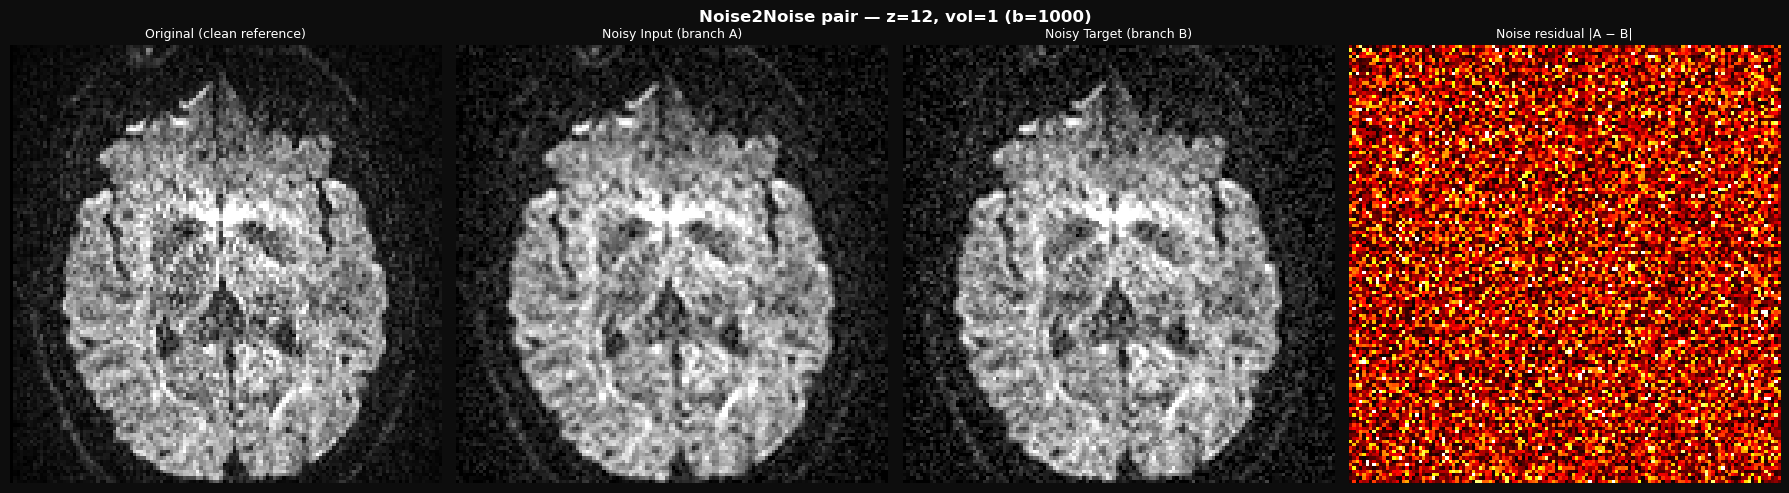

In [40]:
# ─── Degradation functions (k-space + noise) ──────────────────────────────────

def apply_kspace_mask(slice_2d, keep_fraction=0.6):
    """
    Simulate lower-resolution acquisition by zeroing the outer k-space.
    keep_fraction: fraction of k-space to retain (e.g., 0.6 = central 60%).
    """
    kspace  = np.fft.fftshift(np.fft.fft2(slice_2d))
    nx, ny  = kspace.shape
    cx, cy  = nx // 2, ny // 2
    kx = int(nx * keep_fraction / 2)
    ky = int(ny * keep_fraction / 2)
    mask = np.zeros_like(kspace)
    mask[cx-kx:cx+kx, cy-ky:cy+ky] = 1
    return np.abs(np.fft.ifft2(np.fft.ifftshift(kspace * mask)))


def add_gaussian_noise(slice_2d, noise_level):
    """Add zero-mean Gaussian noise; noise_level is relative to slice maximum."""
    sigma = noise_level * np.max(slice_2d)
    return slice_2d + np.random.normal(0, sigma, slice_2d.shape)


def degrade_volume(data, keep_fraction=0.6, noise_min=0.01, noise_max=0.05):
    """
    Apply k-space truncation + random Gaussian noise to every 2-D slice
    in a 4-D DWI volume independently (for Noise2Noise pair generation).
    """
    _, _, Z, T   = data.shape
    degraded     = np.zeros_like(data)
    for t in range(T):
        for z in range(Z):
            s     = data[:, :, z, t]
            s     = apply_kspace_mask(s, keep_fraction)
            level = np.random.uniform(noise_min, noise_max)
            degraded[:, :, z, t] = add_gaussian_noise(s, level)
    return degraded


def plot_noise2noise_pair(original, noisy_a, noisy_b, bvals, z_slice=None, vol_idx=None):
    """
    Show Noise2Noise pair: original | noisy input | noisy target | difference.
    """
    if z_slice is None:
        z_slice = original.shape[2] // 2
    if vol_idx is None:
        dw_idx  = np.where(bvals > 500)[0]
        vol_idx = dw_idx[0] if len(dw_idx) > 0 else 0

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    fig.patch.set_facecolor("#0d0d0d")

    def rot(img): return np.rot90(img)

    imgs = [
        (original[:,:,z_slice,vol_idx], "Original (clean reference)"),
        (noisy_a[:,:,z_slice,vol_idx],  "Noisy Input (branch A)"),
        (noisy_b[:,:,z_slice,vol_idx],  "Noisy Target (branch B)"),
        (np.abs(noisy_a[:,:,z_slice,vol_idx] - noisy_b[:,:,z_slice,vol_idx]),
                                        "Noise residual |A − B|"),
    ]
    cmaps = ["gray", "gray", "gray", "hot"]

    for ax, (img, title), cmap in zip(axes, imgs, cmaps):
        vmax = np.percentile(img, 99)
        ax.imshow(rot(img), cmap=cmap, vmin=0, vmax=vmax)
        ax.set_title(title, color="white", fontsize=9)
        ax.axis("off")

    plt.suptitle(f"Noise2Noise pair — z={z_slice}, vol={vol_idx} (b={bvals[vol_idx]:.0f})",
                 color="white", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()


# ── Generate and visualise a Noise2Noise pair ─────────────────────────────────
sample      = DWI_DATASETS[0]
n2n_config  = DWI_CONFIG

noisy_a = degrade_volume(
    sample["data"],
    keep_fraction=n2n_config["n2n_kspace_keep"],
    noise_min=n2n_config["n2n_noise_min"],
    noise_max=n2n_config["n2n_noise_max"],
)
noisy_b = degrade_volume(
    sample["data"],
    keep_fraction=n2n_config["n2n_kspace_keep"],
    noise_min=n2n_config["n2n_noise_min"],
    noise_max=n2n_config["n2n_noise_max"],
)

plot_noise2noise_pair(sample["data"], noisy_a, noisy_b, sample["bvals"])


---
## DWI Step 6 — Noise2Noise PyTorch Dataset

### Dataset design
Each sample returns `(noisy_input, noisy_target)`:
- Both are independent degradations of the **same** original slice
- The network sees two different noise realisations and must predict their mean
- At inference, only the input branch is needed

### Degradation on-the-fly vs. pre-computed
We generate degraded pairs **on-the-fly** inside `__getitem__`:
- Pros: every epoch sees **different** noise realisations → more regularisation
- Pros: zero storage overhead
- Cons: slightly slower per batch (one k-space FFT per slice)

For large datasets, pre-computing and caching degraded volumes is also an option — see the `precompute_pairs` helper at the bottom of this section.


In [41]:
if TORCH_AVAILABLE:

    class Noise2NoiseDataset(Dataset):
        """
        PyTorch Dataset for Noise2Noise DWI denoising training.

        Each call to __getitem__ generates TWO independent noisy versions of
        the same axial slice on-the-fly, so every epoch sees different noise.

        Parameters
        ----------
        sample       : DWI dataset dict (output of load_dwi_dataset)
        b0_threshold : b-value threshold for filtering out b=0 (optional)
        include_b0   : Include b=0 volumes as training slices (default False)
        keep_fraction: k-space fraction to retain for resolution degradation
        noise_min    : Minimum relative noise level
        noise_max    : Maximum relative noise level
        """
        def __init__(self, sample, b0_threshold=50, include_b0=False,
                     keep_fraction=0.6, noise_min=0.01, noise_max=0.05):
            self.data          = sample["data"]   # (X, Y, Z, N)
            self.bvals         = sample["bvals"]
            self.keep_fraction = keep_fraction
            self.noise_min     = noise_min
            self.noise_max     = noise_max

            # Build index list
            vol_mask = (self.bvals > b0_threshold) if not include_b0                        else np.ones(len(self.bvals), dtype=bool)
            vol_ids  = np.where(vol_mask)[0]
            z_ids    = np.arange(self.data.shape[2])
            self.index = [(z, v) for z in z_ids for v in vol_ids]

        def _degrade(self, slice_2d):
            """Apply k-space mask + independent Gaussian noise to one slice."""
            s     = apply_kspace_mask(slice_2d.astype(np.float64), self.keep_fraction)
            level = np.random.uniform(self.noise_min, self.noise_max)
            return add_gaussian_noise(s, level).astype(np.float32)

        def __len__(self):
            return len(self.index)

        def __getitem__(self, idx):
            z, v = self.index[idx]
            orig = self.data[:, :, z, v].astype(np.float32)

            # Two independent degradations
            noisy_in  = self._degrade(orig)
            noisy_tgt = self._degrade(orig)

            # Per-slice normalisation (same scale for both)
            vmax = orig.max() + 1e-8
            noisy_in  /= vmax
            noisy_tgt /= vmax

            return (
                torch.from_numpy(noisy_in).unsqueeze(0),   # (1, X, Y)
                torch.from_numpy(noisy_tgt).unsqueeze(0),
            )


    def precompute_n2n_pairs(sample, config, n_pairs=2):
        """
        Pre-compute n_pairs degraded versions of the full 4D volume and
        save them to disk as .npy files for faster DataLoader iteration.
        Returns a list of (path_input, path_target) tuples.
        """
        out_dir = config["output_dir"]
        os.makedirs(out_dir, exist_ok=True)
        saved = []
        for i in range(n_pairs):
            a = degrade_volume(sample["data"], config["n2n_kspace_keep"],
                               config["n2n_noise_min"], config["n2n_noise_max"])
            b = degrade_volume(sample["data"], config["n2n_kspace_keep"],
                               config["n2n_noise_min"], config["n2n_noise_max"])
            pa = os.path.join(out_dir, f"{sample['name']}_n2n_input_{i}.npy")
            pb = os.path.join(out_dir, f"{sample['name']}_n2n_target_{i}.npy")
            np.save(pa, a); np.save(pb, b)
            saved.append((pa, pb))
            print(f"  ✓ Saved pair {i}: {os.path.basename(pa)}  +  {os.path.basename(pb)}")
        return saved


    # ── Instantiate and test ──────────────────────────────────────────────────
    n2n_dataset = Noise2NoiseDataset(
        sample=DWI_DATASETS[0],
        b0_threshold=DWI_CONFIG["b0_threshold"],
        keep_fraction=DWI_CONFIG["n2n_kspace_keep"],
        noise_min=DWI_CONFIG["n2n_noise_min"],
        noise_max=DWI_CONFIG["n2n_noise_max"],
    )
    n2n_loader = DataLoader(n2n_dataset, batch_size=DWI_CONFIG["batch_size"],
                            shuffle=True, num_workers=DWI_CONFIG["num_workers"])

    in_batch, tgt_batch = next(iter(n2n_loader))

    print("✅ Noise2NoiseDataset ready!")
    print(f"   Total slices        : {len(n2n_dataset)}")
    print(f"   Batch input shape   : {list(in_batch.shape)}")
    print(f"   Batch target shape  : {list(tgt_batch.shape)}")
    print(f"   Value range (input) : [{in_batch.min():.3f}, {in_batch.max():.3f}]")
    print()
    print("Tip: use precompute_n2n_pairs() to save degraded volumes to disk for faster training.")

else:
    print("⚠️  PyTorch not available — skipping Noise2NoiseDataset demo.")


✅ Noise2NoiseDataset ready!
   Total slices        : 3200
   Batch input shape   : [2, 1, 130, 132]
   Batch target shape  : [2, 1, 130, 132]
   Value range (input) : [-0.047, 0.986]

Tip: use precompute_n2n_pairs() to save degraded volumes to disk for faster training.


---
## DWI Step 7 — Visual Comparison: Raw vs. Patch2Self vs. Noise2Noise Reconstruction

Here we compare the three versions side-by-side:
- **Raw** — original noisy DWI
- **Patch2Self** — analytically denoised (reference)
- **N2N reconstruction** — average of many synthetic degradations (approximates Noise2Noise inference output)

The N2N reconstruction shown here is *not* a trained network output — it's the **expected value** of the degradation, which is what a perfectly trained N2N network would learn to predict. It serves as an intuitive illustration of the training target.


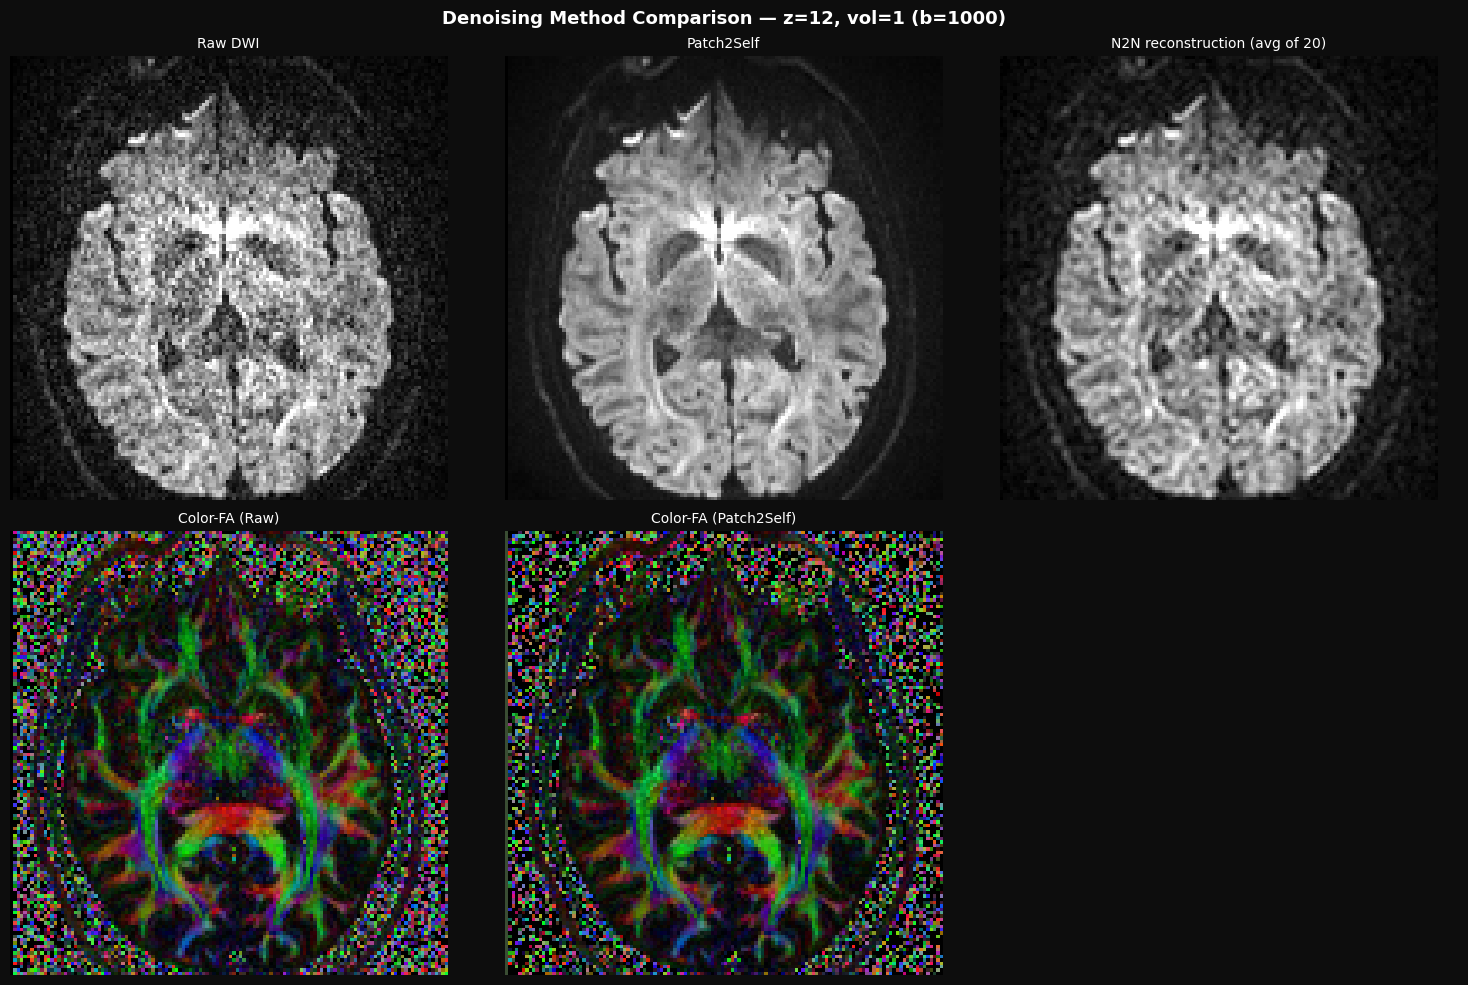

In [42]:
def plot_method_comparison(sample, p2s_clean, bvals, z_slice=None, n_avg=20):
    """
    Compare raw DWI, Patch2Self output, and N2N expected reconstruction
    for both image space and Color-FA maps.
    """
    if z_slice is None:
        z_slice = sample["data"].shape[2] // 2
    dw_idx  = np.where(bvals > 500)[0]
    v       = dw_idx[0] if len(dw_idx) > 0 else 0

    # N2N expected reconstruction: average of many independent degradations
    degradations = np.stack([
        degrade_volume(
            sample["data"],
            keep_fraction=DWI_CONFIG["n2n_kspace_keep"],
            noise_min=DWI_CONFIG["n2n_noise_min"],
            noise_max=DWI_CONFIG["n2n_noise_max"],
        )[:, :, z_slice, v]
        for _ in range(n_avg)
    ], axis=0)
    n2n_recon = degradations.mean(axis=0)

    raw_sl   = sample["data"][:, :, z_slice, v]
    p2s_sl   = p2s_clean[:, :, z_slice, v]

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.patch.set_facecolor("#0d0d0d")

    def rot(x): return np.rot90(x)

    # Row 1 — image space
    vmax = np.percentile(raw_sl, 99)
    for ax, img, title in zip(
        axes[0],
        [raw_sl, p2s_sl, n2n_recon],
        ["Raw DWI", "Patch2Self", f"N2N reconstruction (avg of {n_avg})"]
    ):
        ax.imshow(rot(img), cmap="gray", vmin=0, vmax=vmax)
        ax.set_title(title, color="white", fontsize=10)
        ax.axis("off")

    # Row 2 — Color-FA maps (only if DIPY available)
    if DIPY_AVAILABLE:
        gtab = sample["gtab"]
        def cfa(vol4d):
            sl = vol4d[:, :, z_slice:z_slice+1, :]
            return np.clip(
                compute_color_fa(tensor_to_6d(compute_dti(sl, gtab)))[:,:,0,:], 0, 1
            )
        for ax, vol4d, title in zip(
            axes[1],
            [sample["data"], p2s_clean, None],
            ["Color-FA (Raw)", "Color-FA (Patch2Self)", ""]
        ):
            if vol4d is not None:
                ax.imshow(rot(cfa(vol4d))); ax.set_title(title, color="white", fontsize=10)
            ax.axis("off")
    else:
        for ax in axes[1]:
            ax.axis("off")
        axes[1, 1].text(0.5, 0.5, "Color-FA requires dipy",
                        ha="center", va="center", color="white", transform=axes[1,1].transAxes)

    plt.suptitle(f"Denoising Method Comparison — z={z_slice}, vol={v} (b={bvals[v]:.0f})",
                 color="white", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


plot_method_comparison(DWI_DATASETS[0], p2s_denoised, DWI_DATASETS[0]["bvals"])


---
## DWI Step 8 — Connecting the Datasets to the U-Net

### Architecture recap
Your `UNet` in `UnetCore.py` is a 3D U-Net. For **2D slice-based DWI denoising** we use it in 2D mode by treating the DWI slices as single-channel 2D images — shape `(1, X, Y)`.

A 2D U-Net is identical in structure but uses `nn.Conv2d` / `nn.MaxPool2d` etc.  
Alternatively, your existing 3D U-Net can be used on full 3D volumes with the 4th dimension (gradient direction) treated as the channel axis.

### Training loop sketch
Below is a minimal training loop that works with **both** datasets.  
Swap `train_dataset` between `Patch2SelfDataset` and `Noise2NoiseDataset` — the rest stays the same.


In [43]:
# ─── Minimal 2D U-Net wrapper & training loop sketch ─────────────────────────
# (Paste this into your training script; it shows how both datasets plug in)

if TORCH_AVAILABLE:
    import torch.nn as nn
    import torch.optim as optim

    # ── Lightweight 2D double-conv block ─────────────────────────────────────
    class DoubleConv2d(nn.Module):
        def __init__(self, in_ch, out_ch):
            super().__init__()
            self.net = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
                nn.InstanceNorm2d(out_ch), nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
                nn.InstanceNorm2d(out_ch), nn.ReLU(inplace=True),
            )
        def forward(self, x): return self.net(x)

    class UNet2D(nn.Module):
        """Minimal 2D U-Net for DWI slice denoising. Same logic as UnetCore.py."""
        def __init__(self, in_ch=1, out_ch=1, features=32):
            super().__init__()
            self.e1 = DoubleConv2d(in_ch, features)
            self.e2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv2d(features,   features*2))
            self.e3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv2d(features*2, features*4))
            self.bn = nn.Sequential(nn.MaxPool2d(2), DoubleConv2d(features*4, features*8))
            self.d3 = nn.Sequential(
                nn.ConvTranspose2d(features*8, features*4, 2, 2),)
            self.c3 = DoubleConv2d(features*8, features*4)
            self.d2 = nn.ConvTranspose2d(features*4, features*2, 2, 2)
            self.c2 = DoubleConv2d(features*4, features*2)
            self.d1 = nn.ConvTranspose2d(features*2, features, 2, 2)
            self.c1 = DoubleConv2d(features*2, features)
            self.out = nn.Conv2d(features, out_ch, 1)

        @staticmethod
        def _pad_to_match(upsampled, skip):
            """Pad upsampled tensor to match skip connection size if off by 1 pixel."""
            dh = skip.shape[2] - upsampled.shape[2]
            dw = skip.shape[3] - upsampled.shape[3]
            if dh > 0 or dw > 0:
                upsampled = torch.nn.functional.pad(
                    upsampled, [dw // 2, dw - dw // 2, dh // 2, dh - dh // 2]
                )
            return upsampled

        def forward(self, x):
            s1 = self.e1(x);  s2 = self.e2(s1);  s3 = self.e3(s2)
            x  = self.bn(s3)
            x  = self.c3(torch.cat([s3, self._pad_to_match(self.d3(x), s3)], dim=1))
            x  = self.c2(torch.cat([s2, self._pad_to_match(self.d2(x), s2)], dim=1))
            x  = self.c1(torch.cat([s1, self._pad_to_match(self.d1(x), s1)], dim=1))
            return self.out(x)

    # ── Verify shapes ─────────────────────────────────────────────────────────
    _model   = UNet2D(in_ch=1, out_ch=1, features=32)
    _n_params = sum(p.numel() for p in _model.parameters() if p.requires_grad)
    _dummy   = torch.randn(2, 1, 64, 64)
    _out     = _model(_dummy)
    print(f"✅ UNet2D instantiated — {_n_params:,} trainable parameters")
    print(f"   Input  shape: {list(_dummy.shape)}")
    print(f"   Output shape: {list(_out.shape)}")
    print()

    # ── Training loop sketch ──────────────────────────────────────────────────
    def train_denoiser(model, train_loader, n_epochs=3, lr=1e-3, device="cpu"):
        """
        Generic training loop — works with Patch2SelfDataset AND Noise2NoiseDataset.
        Both return (input_tensor, target_tensor) pairs of shape (B, 1, X, Y).
        """
        model   = model.to(device)
        opt     = optim.Adam(model.parameters(), lr=lr)
        loss_fn = nn.MSELoss()

        for epoch in range(1, n_epochs + 1):
            model.train()
            total_loss = 0.0
            for step, (inp, tgt) in enumerate(train_loader):
                inp, tgt = inp.to(device), tgt.to(device)
                pred = model(inp)
                loss = loss_fn(pred, tgt)
                opt.zero_grad(); loss.backward(); opt.step()
                total_loss += loss.item()

            avg = total_loss / len(train_loader)
            print(f"  Epoch {epoch}/{n_epochs}  —  avg MSE loss: {avg:.6f}")

        return model


    print("─── Patch2Self training run (3 epochs, demo) ───")
    model_p2s = UNet2D()
    model_p2s = train_denoiser(model_p2s, p2s_loader, n_epochs=3)

    print()
    print("─── Noise2Noise training run (3 epochs, demo) ───")
    model_n2n = UNet2D()
    model_n2n = train_denoiser(model_n2n, n2n_loader, n_epochs=3)

else:
    print("⚠️  PyTorch not available — skipping U-Net demo.")


✅ UNet2D instantiated — 1,923,617 trainable parameters
   Input  shape: [2, 1, 64, 64]
   Output shape: [2, 1, 64, 64]

─── Patch2Self training run (3 epochs, demo) ───
  Epoch 1/3  —  avg MSE loss: 0.002191
  Epoch 2/3  —  avg MSE loss: 0.001133
  Epoch 3/3  —  avg MSE loss: 0.001044

─── Noise2Noise training run (3 epochs, demo) ───
  Epoch 1/3  —  avg MSE loss: 0.002832
  Epoch 2/3  —  avg MSE loss: 0.001478
  Epoch 3/3  —  avg MSE loss: 0.001429


---
## DWI Step 9 — Saving Denoised Data to Disk

After training, you typically want to:
1. Run inference on all datasets with the trained model
2. Save the denoised 4D volumes as `.nii.gz` for use in downstream DTI analysis
3. Optionally save the denoised slices as `.npy` for fast reloading


In [44]:
def save_denoised_nifti(data, affine, out_path):
    """Save a denoised 4D DWI volume as a NIfTI file."""
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    img = nib.Nifti1Image(data.astype(np.float32), affine)
    nib.save(img, out_path)
    size_mb = os.path.getsize(out_path) / 1024**2
    print(f"  ✓ Saved → {out_path}  ({size_mb:.1f} MB)")


def inference_and_save(model, dataset_dict, p2s_denoised, out_dir, device="cpu"):
    """
    Run UNet2D inference slice-by-slice on one DWI dataset and
    reconstruct the full 4D denoised volume.
    """
    if not TORCH_AVAILABLE:
        print("⚠️  PyTorch required for inference.")
        return

    model.eval()
    data   = dataset_dict["data"]   # (X, Y, Z, N)
    bvals  = dataset_dict["bvals"]
    X, Y, Z, N = data.shape
    recon  = np.zeros_like(data)

    with torch.no_grad():
        for v in range(N):
            for z in range(Z):
                sl   = data[:, :, z, v].astype(np.float32)
                vmax = sl.max() + 1e-8
                inp  = torch.from_numpy(sl / vmax).unsqueeze(0).unsqueeze(0).to(device)
                out  = model(inp).squeeze().cpu().numpy() * vmax
                recon[:, :, z, v] = out

    # Save both Patch2Self and network-denoised versions
    os.makedirs(out_dir, exist_ok=True)
    name = dataset_dict["name"]

    # Patch2Self result
    p2s_path = os.path.join(out_dir, f"{name}_patch2self.nii.gz")
    save_denoised_nifti(p2s_denoised, dataset_dict["affine"], p2s_path)

    # Network (N2N or P2S-supervised) result
    net_path = os.path.join(out_dir, f"{name}_network_denoised.nii.gz")
    save_denoised_nifti(recon, dataset_dict["affine"], net_path)

    # Also save gradient files alongside (needed for downstream DTI)
    import shutil
    for ext in [".bval", ".bvec"]:
        src = dataset_dict["path"].replace(".nii.gz", ext)
        if os.path.exists(src):
            shutil.copy(src, os.path.join(out_dir, f"{name}{ext}"))
            print(f"  ✓ Copied {os.path.basename(src)}")

    return recon


# ── Run inference on first dataset ───────────────────────────────────────────
print("Running inference with N2N-trained model...")
recon_vol = inference_and_save(
    model=model_n2n,
    dataset_dict=DWI_DATASETS[0],
    p2s_denoised=p2s_denoised,
    out_dir=DWI_CONFIG["output_dir"],
)

if recon_vol is not None:
    print()
    print(f"Reconstruction shape : {recon_vol.shape}")
    print(f"Value range          : [{recon_vol.min():.1f}, {recon_vol.max():.1f}]")


Running inference with N2N-trained model...
  ✓ Saved → ./preprocessed_dwi/sub-01_ses-1_dwi_patch2self.nii.gz  (189.0 MB)
  ✓ Saved → ./preprocessed_dwi/sub-01_ses-1_dwi_network_denoised.nii.gz  (191.2 MB)
  ✓ Copied sub-01_ses-1_dwi.bval
  ✓ Copied sub-01_ses-1_dwi.bvec

Reconstruction shape : (130, 132, 25, 130)
Value range          : [-317.2, 6093.2]




### Key parameters to tune

| Parameter | Effect |
|-----------|--------|
| `n2n_kspace_keep` | Lower = more resolution degradation, stronger regularisation |
| `n2n_noise_min/max` | Higher = noisier pairs, more robust to thermal noise |
| `features` in UNet2D | More features = stronger model, slower training |
| `include_b0=True` | Include b=0 slices (higher SNR, can help anchor training) |